11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.2140 - val_loss: 0.1535
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1417 - val_loss: 0.1316
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1286 - val_loss: 0.1231
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1220 - val_loss: 0.1174
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1170 - val_loss: 0.1140
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1142 - val_loss: 0.1117
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1121 - val_loss: 0.1099
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1101 - val_loss: 0.1078
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1084 - val_loss: 0.1064
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1072 - val_loss: 0.1055
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1062 - val_loss: 0.1044
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

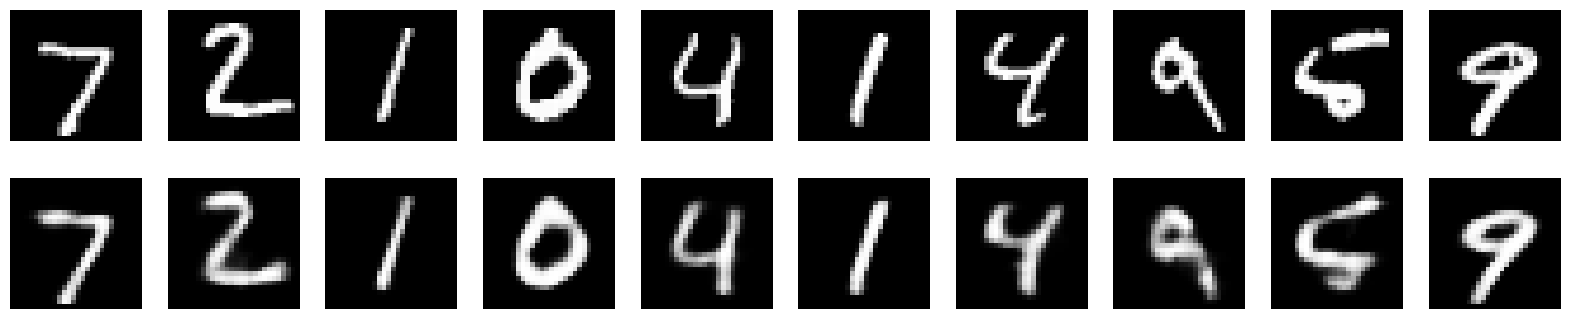

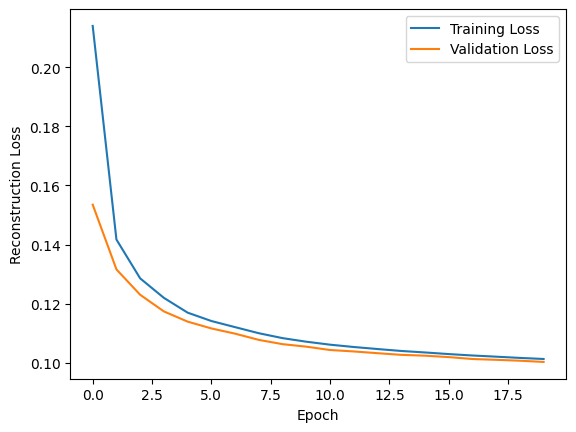

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense


(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)


input_layer = Input(shape=(784,))

x = Dense(128, activation="relu")(input_layer)
x = Dense(32, activation="relu")(x)

latent = Dense(16, activation="relu")(x)

x = Dense(32, activation="relu")(latent)
x = Dense(128, activation="relu")(x)

output_layer = Dense(784, activation="sigmoid")(x)

autoencoder = Model(input_layer, output_layer)


autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, x_test)
)


reconstructed = autoencoder.predict(x_test)


n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.legend()
plt.show()

In [2]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    x_test.flatten(),
    reconstructed.flatten()
)

print("Test MSE:", mse)

Test MSE: 0.012705283239483833


In [3]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    x_test.flatten(),
    reconstructed.flatten()
)

print("Test MAE:", mae)

Test MAE: 0.03926975280046463


In [4]:
!pip install scikit-image

In [5]:
x_test_images = x_test.reshape(-1, 28, 28)
reconstructed_images = reconstructed.reshape(-1, 28, 28)

In [6]:
from skimage.metrics import structural_similarity as ssim

In [7]:
ssim_scores = []

for i in range(len(x_test_images)):

    score = ssim(
        x_test_images[i],
        reconstructed_images[i],
        data_range=1.0
    )

    ssim_scores.append(score)

In [8]:
mean_ssim = np.mean(ssim_scores)

print("Mean SSIM:", mean_ssim)

Mean SSIM: 0.85928931939776


In [9]:
print("========== TEST RESULTS ==========")
print("MSE :", mse)
print("MAE :", mae)
print("SSIM:", mean_ssim)

========== TEST RESULTS ==========
MSE : 0.012705283239483833
MAE : 0.03926975280046463
SSIM: 0.85928931939776



Error array shape: (10000,)


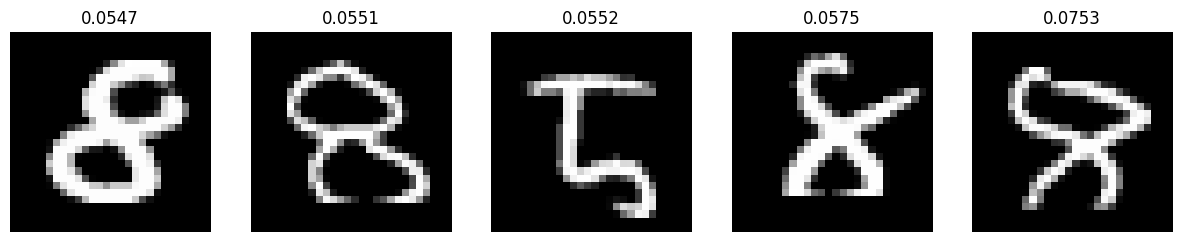

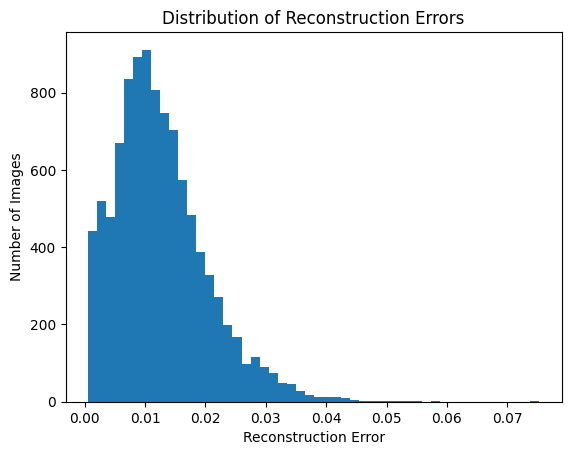

In [10]:
image_errors = np.mean(
    (x_test - reconstructed) ** 2,
    axis=1
)

print("\nError array shape:", image_errors.shape)

highest_error_indices = np.argsort(image_errors)[-5:]

plt.figure(figsize=(15, 3))

for i, idx in enumerate(highest_error_indices):

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        x_test[idx].reshape(28, 28),
        cmap="gray"
    )

    plt.title(f"{image_errors[idx]:.4f}")
    plt.axis("off")

plt.show()


plt.hist(image_errors, bins=50)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Images")
plt.title("Distribution of Reconstruction Errors")

plt.show()

In [11]:

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)


x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

print("Training:", x_train_cnn.shape)
print("Testing :", x_test_cnn.shape)


input_layer = Input(shape=(28, 28, 1))


x = Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(input_layer)

x = MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

x = Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

x = Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)



x = UpSampling2D((2, 2))(x)

x = Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = UpSampling2D((2, 2))(x)

output_layer = Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same"
)(x)



conv_autoencoder = Model(
    input_layer,
    output_layer
)


conv_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)


# ==========================================
# 7. SUMMARY
# ==========================================

conv_autoencoder.summary()

Training: (60000, 28, 28, 1)
Testing : (10000, 28, 28, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 0.1031 - val_loss: 0.0733
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0721 - val_loss: 0.0701
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0696 - val_loss: 0.0682
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0683 - val_loss: 0.0672
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0673 - val_loss: 0.0664
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0665 - val_loss: 0.0659
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0660 - val_loss: 0.0653
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0656 - val_loss: 0.0650
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0652 - val_loss: 0.0651
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0649 - val_loss: 0.0644
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0647 - val_loss: 0.0641
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/st

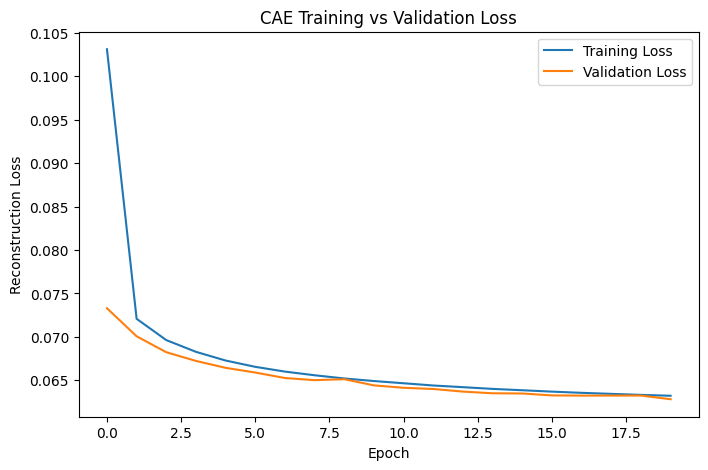

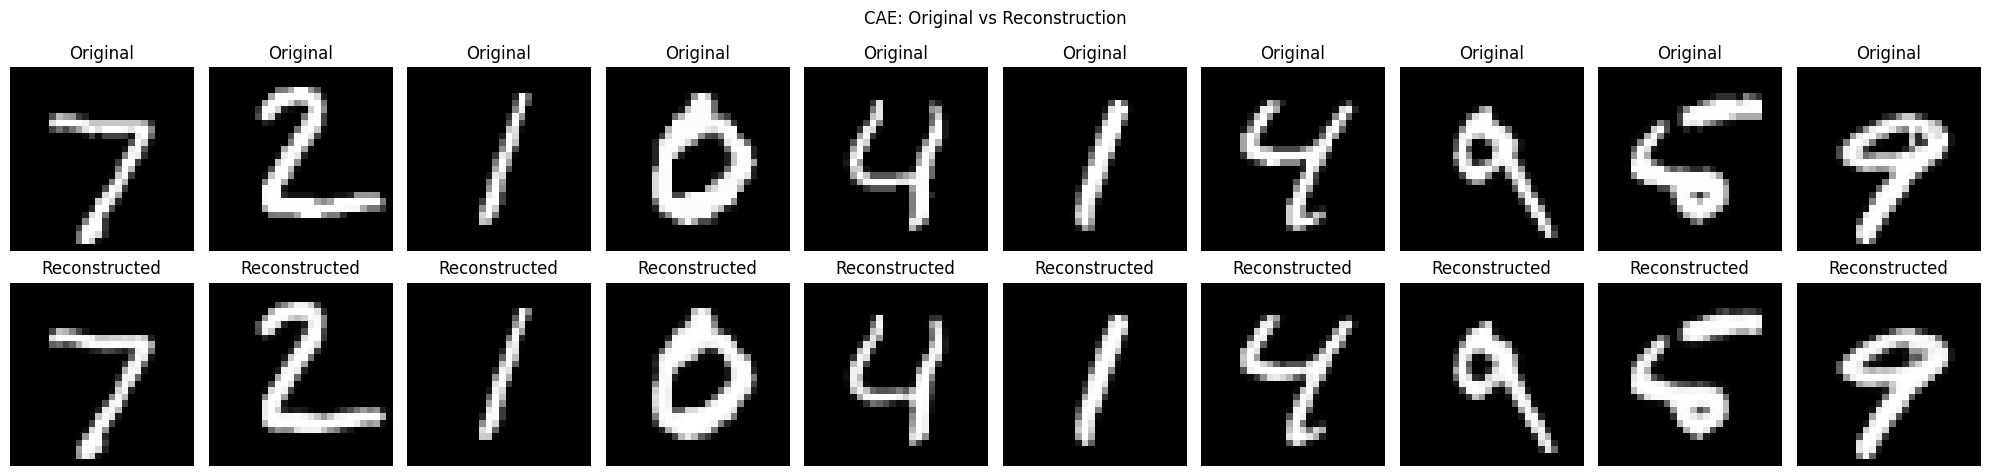

Error array shape: (10000,)


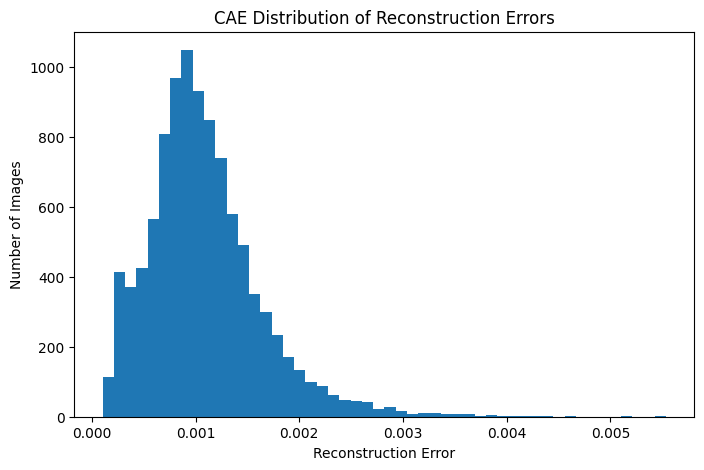

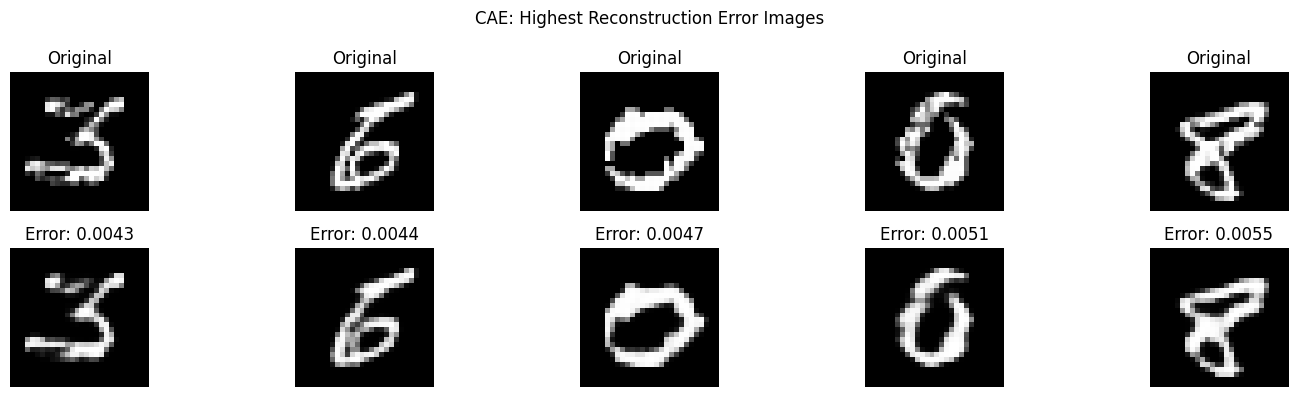

In [12]:

history_cae = conv_autoencoder.fit(
    x_train_cnn,
    x_train_cnn,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_cnn, x_test_cnn)
)


reconstructed_cae = conv_autoencoder.predict(
    x_test_cnn
)



plt.figure(figsize=(8, 5))

plt.plot(
    history_cae.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cae.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("CAE Training vs Validation Loss")

plt.legend()
plt.show()


n = 10

plt.figure(figsize=(20, 5))

for i in range(n):

    # Original
    plt.subplot(2, n, i + 1)

    plt.imshow(
        x_test_cnn[i].squeeze(),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")


    # Reconstruction
    plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        reconstructed_cae[i].squeeze(),
        cmap="gray"
    )

    plt.title("Reconstructed")
    plt.axis("off")

plt.suptitle("CAE: Original vs Reconstruction")
plt.tight_layout()
plt.show()



# Mean Squared Error for every image

cae_image_errors = np.mean(
    (x_test_cnn - reconstructed_cae) ** 2,
    axis=(1, 2, 3)
)

print("Error array shape:", cae_image_errors.shape)


plt.figure(figsize=(8, 5))

plt.hist(
    cae_image_errors,
    bins=50
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Images")
plt.title("CAE Distribution of Reconstruction Errors")

plt.show()


highest_error_indices = np.argsort(
    cae_image_errors
)[-5:]

plt.figure(figsize=(15, 4))

for i, idx in enumerate(highest_error_indices):

    # Original
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test_cnn[idx].squeeze(),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")


    # Reconstruction
    plt.subplot(2, 5, i + 6)

    plt.imshow(
        reconstructed_cae[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Error: {cae_image_errors[idx]:.4f}"
    )

    plt.axis("off")


plt.suptitle("CAE: Highest Reconstruction Error Images")
plt.tight_layout()
plt.show()


       FC-AE vs CONVOLUTIONAL AE

Fully Connected Autoencoder
------------------------------------------
MSE        : 0.012705283239483833
MAE        : 0.03926975280046463
SSIM       : 0.85928931939776
Parameters : 211040

Convolutional Autoencoder
------------------------------------------
MSE        : 0.0010859312023967505
MAE        : 0.009741229936480522
SSIM       : 0.9896719765204384
Parameters : 74497


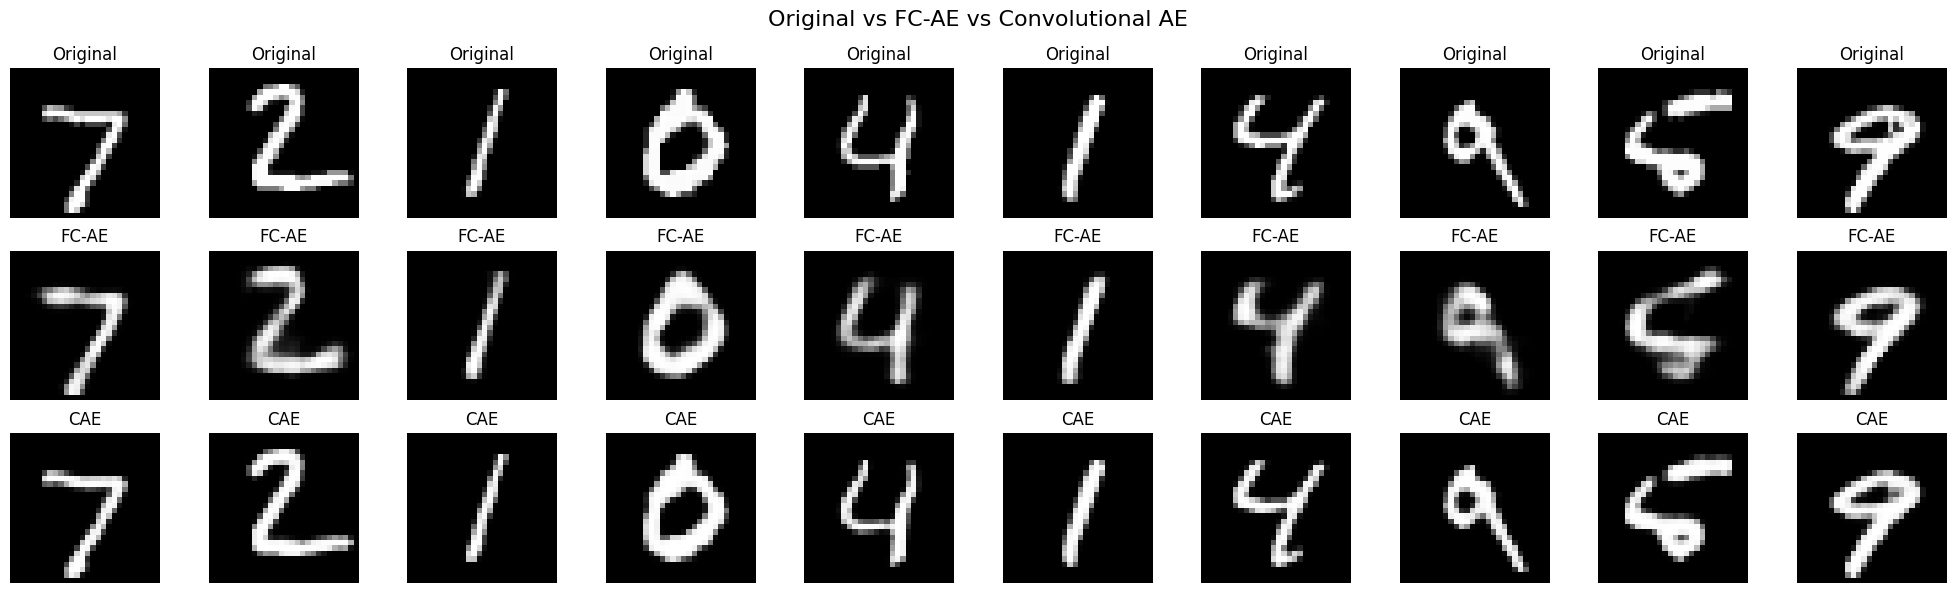

In [13]:


from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim
import numpy as np
import matplotlib.pyplot as plt


fc_original = x_test.reshape(-1, 28, 28)
fc_reconstructed = reconstructed.reshape(-1, 28, 28)


cae_original = x_test_cnn.squeeze()
cae_reconstructed = reconstructed_cae.squeeze()

fc_mse = mean_squared_error(
    fc_original.flatten(),
    fc_reconstructed.flatten()
)


fc_mae = mean_absolute_error(
    fc_original.flatten(),
    fc_reconstructed.flatten()
)


fc_ssim_scores = []

for i in range(len(fc_original)):

    score = ssim(
        fc_original[i],
        fc_reconstructed[i],
        data_range=1.0
    )

    fc_ssim_scores.append(score)

fc_ssim = np.mean(fc_ssim_scores)


cae_mse = mean_squared_error(
    cae_original.flatten(),
    cae_reconstructed.flatten()
)


cae_mae = mean_absolute_error(
    cae_original.flatten(),
    cae_reconstructed.flatten()
)

cae_ssim_scores = []

for i in range(len(cae_original)):

    score = ssim(
        cae_original[i],
        cae_reconstructed[i],
        data_range=1.0
    )

    cae_ssim_scores.append(score)

cae_ssim = np.mean(cae_ssim_scores)


fc_params = autoencoder.count_params()

cae_params = conv_autoencoder.count_params()


print("\n==========================================")
print("       FC-AE vs CONVOLUTIONAL AE")
print("==========================================")

print("\nFully Connected Autoencoder")
print("------------------------------------------")
print("MSE        :", fc_mse)
print("MAE        :", fc_mae)
print("SSIM       :", fc_ssim)
print("Parameters :", fc_params)


print("\nConvolutional Autoencoder")
print("------------------------------------------")
print("MSE        :", cae_mse)
print("MAE        :", cae_mae)
print("SSIM       :", cae_ssim)
print("Parameters :", cae_params)


n = 10

plt.figure(figsize=(20, 6))

for i in range(n):


    plt.subplot(3, n, i + 1)

    plt.imshow(
        fc_original[i],
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")



    plt.subplot(3, n, i + 1 + n)

    plt.imshow(
        fc_reconstructed[i],
        cmap="gray"
    )

    plt.title("FC-AE")
    plt.axis("off")



    plt.subplot(3, n, i + 1 + 2*n)

    plt.imshow(
        cae_reconstructed[i],
        cmap="gray"
    )

    plt.title("CAE")
    plt.axis("off")


plt.suptitle(
    "Original vs FC-AE vs Convolutional AE",
    fontsize=16
)

plt.tight_layout()
plt.show()

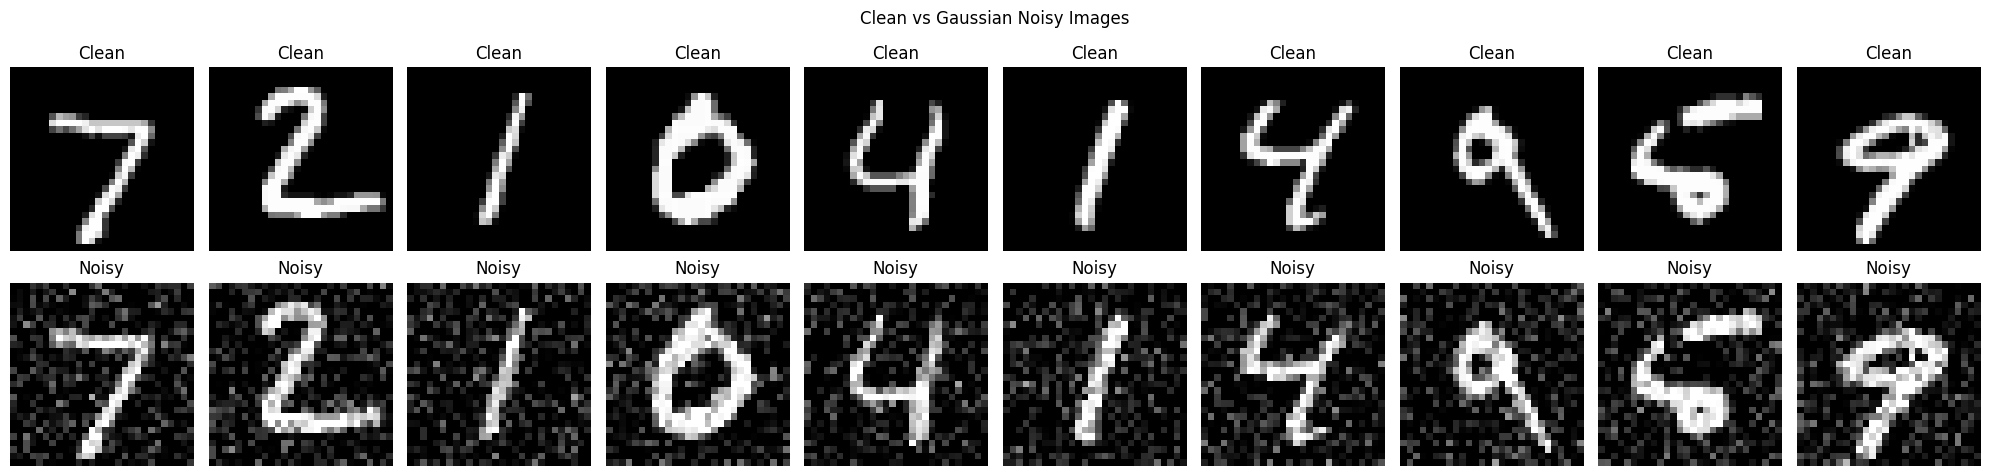

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0741 - val_loss: 0.0718
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0717 - val_loss: 0.0709
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0712 - val_loss: 0.0711
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0709 - val_loss: 0.0703
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0707 - val_loss: 0.0702
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0705 - val_loss: 0.0701
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0704 - val_loss: 0.0699
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0703 - val_loss: 0.0700
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0702 - val_loss: 0.0698
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0701 - val_loss: 0.0697
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0700 - val_loss: 0.0696
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/ste

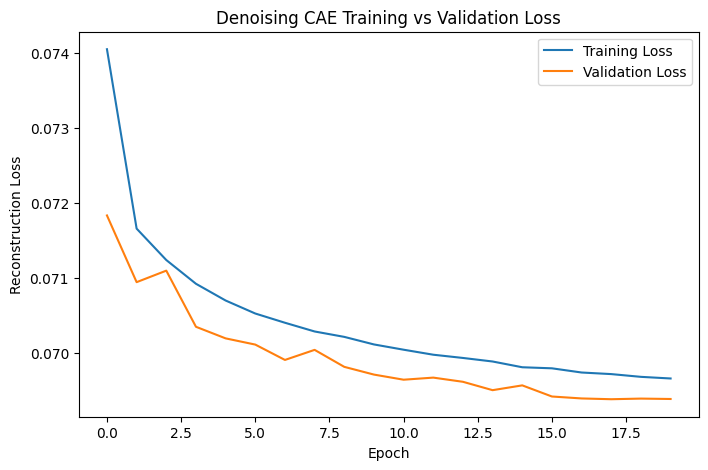

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


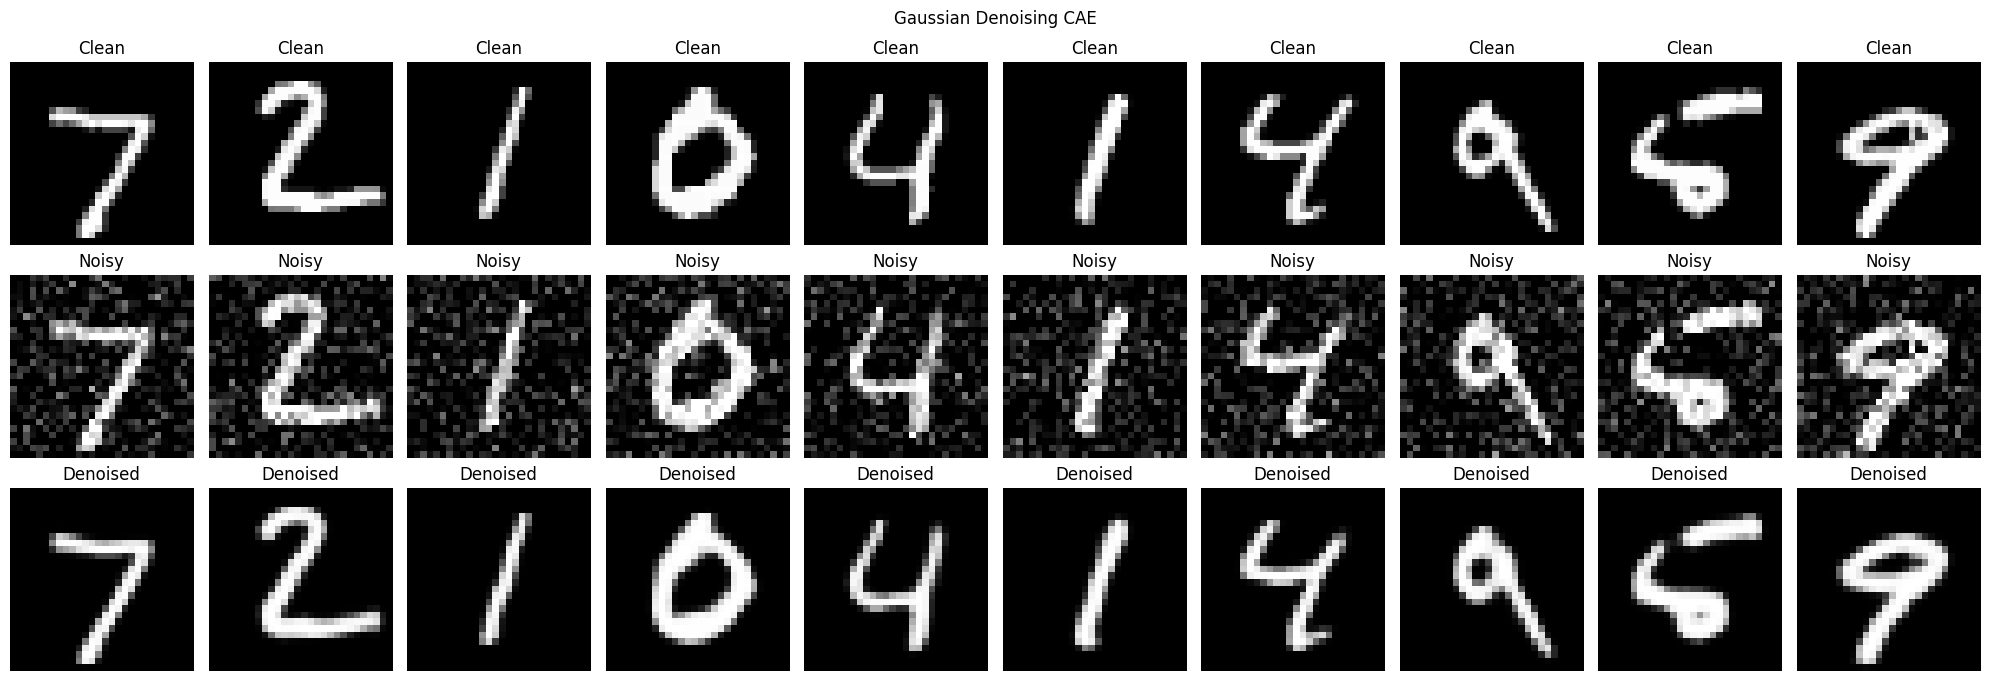


     GAUSSIAN DENOISING CAE
Noise level (sigma): 0.2
MSE : 0.002855333499610424
MAE : 0.016359347850084305
SSIM: 0.9637735082809525

Error array shape: (10000,)


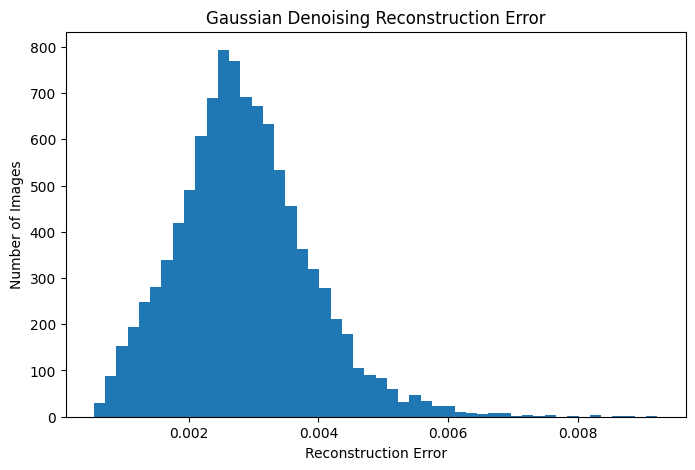

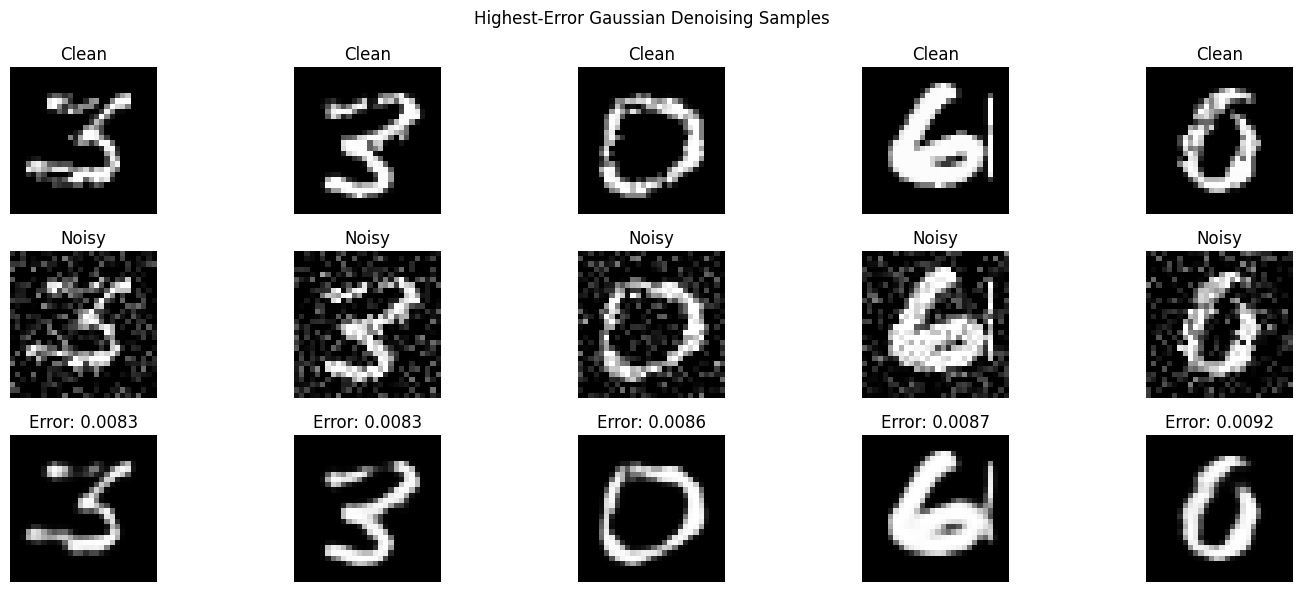

In [14]:


noise_factor = 0.2

train_noise = np.random.normal(
    0,
    noise_factor,
    x_train_cnn.shape
)

test_noise = np.random.normal(
    0,
    noise_factor,
    x_test_cnn.shape
)

# Add noise
x_train_noisy = x_train_cnn + train_noise
x_test_noisy = x_test_cnn + test_noise

# Keep pixels between 0 and 1
x_train_noisy = np.clip(
    x_train_noisy,
    0,
    1
)

x_test_noisy = np.clip(
    x_test_noisy,
    0,
    1
)



n = 10

plt.figure(figsize=(20, 5))

for i in range(n):

    # Clean image
    plt.subplot(2, n, i + 1)

    plt.imshow(
        x_test_cnn[i].squeeze(),
        cmap="gray"
    )

    plt.title("Clean")
    plt.axis("off")


    # Noisy image
    plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        x_test_noisy[i].squeeze(),
        cmap="gray"
    )

    plt.title("Noisy")
    plt.axis("off")


plt.suptitle(
    "Clean vs Gaussian Noisy Images"
)

plt.tight_layout()
plt.show()



denoising_cae = Model(
    conv_autoencoder.input,
    conv_autoencoder.output
)

denoising_cae.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)



history_denoising = denoising_cae.fit(
    x_train_noisy,       # INPUT = NOISY
    x_train_cnn,         # TARGET = CLEAN

    epochs=20,
    batch_size=128,

    validation_data=(
        x_test_noisy,    # noisy validation input
        x_test_cnn       # clean validation target
    )
)


plt.figure(figsize=(8, 5))

plt.plot(
    history_denoising.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_denoising.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")

plt.title(
    "Denoising CAE Training vs Validation Loss"
)

plt.legend()
plt.show()


# ============================================================
# 6. DENOISE TEST IMAGES
# ============================================================

denoised = denoising_cae.predict(
    x_test_noisy
)


# ============================================================
# 7. CLEAN VS NOISY VS DENOISED
# ============================================================

n = 10

plt.figure(figsize=(20, 7))

for i in range(n):

    # -----------------------------
    # CLEAN
    # -----------------------------

    plt.subplot(3, n, i + 1)

    plt.imshow(
        x_test_cnn[i].squeeze(),
        cmap="gray"
    )

    plt.title("Clean")
    plt.axis("off")


    # -----------------------------
    # NOISY
    # -----------------------------

    plt.subplot(3, n, i + 1 + n)

    plt.imshow(
        x_test_noisy[i].squeeze(),
        cmap="gray"
    )

    plt.title("Noisy")
    plt.axis("off")


    # -----------------------------
    # DENOISED
    # -----------------------------

    plt.subplot(3, n, i + 1 + 2*n)

    plt.imshow(
        denoised[i].squeeze(),
        cmap="gray"
    )

    plt.title("Denoised")
    plt.axis("off")


plt.suptitle(
    "Gaussian Denoising CAE"
)

plt.tight_layout()
plt.show()


# ============================================================
# 8. MSE
# Compare DENOISED with CLEAN
# ============================================================

denoise_mse = mean_squared_error(
    x_test_cnn.flatten(),
    denoised.flatten()
)


# ============================================================
# 9. MAE
# ============================================================

denoise_mae = mean_absolute_error(
    x_test_cnn.flatten(),
    denoised.flatten()
)


# ============================================================
# 10. SSIM
# ============================================================

denoise_ssim_scores = []

for i in range(len(x_test_cnn)):

    score = ssim(
        x_test_cnn[i].squeeze(),
        denoised[i].squeeze(),
        data_range=1.0
    )

    denoise_ssim_scores.append(score)


denoise_ssim = np.mean(
    denoise_ssim_scores
)


# ============================================================
# 11. PRINT RESULTS
# ============================================================

print("\n======================================")
print("     GAUSSIAN DENOISING CAE")
print("======================================")

print("Noise level (sigma):", noise_factor)

print("MSE :", denoise_mse)
print("MAE :", denoise_mae)
print("SSIM:", denoise_ssim)


# ============================================================
# 12. PER-IMAGE RECONSTRUCTION ERROR
# ============================================================

denoise_errors = np.mean(
    (x_test_cnn - denoised) ** 2,
    axis=(1, 2, 3)
)

print(
    "\nError array shape:",
    denoise_errors.shape
)


# ============================================================
# 13. ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    denoise_errors,
    bins=50
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Images")

plt.title(
    "Gaussian Denoising Reconstruction Error"
)

plt.show()




highest_error_indices = np.argsort(
    denoise_errors
)[-5:]


plt.figure(figsize=(15, 6))

for i, idx in enumerate(highest_error_indices):

    # Original clean
    plt.subplot(3, 5, i + 1)

    plt.imshow(
        x_test_cnn[idx].squeeze(),
        cmap="gray"
    )

    plt.title("Clean")
    plt.axis("off")


    # Noisy
    plt.subplot(3, 5, i + 6)

    plt.imshow(
        x_test_noisy[idx].squeeze(),
        cmap="gray"
    )

    plt.title("Noisy")
    plt.axis("off")


    # Denoised
    plt.subplot(3, 5, i + 11)

    plt.imshow(
        denoised[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Error: {denoise_errors[idx]:.4f}"
    )

    plt.axis("off")


plt.suptitle(
    "Highest-Error Gaussian Denoising Samples"
)

plt.tight_layout()
plt.show()



        GAUSSIAN NOISE σ = 0.1
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0659 - val_loss: 0.0651
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0653 - val_loss: 0.0649
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0652 - val_loss: 0.0650
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0652 - val_loss: 0.0648
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0651 - val_loss: 0.0648
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0651 - val_loss: 0.0648
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0650 - val_loss: 0.0647
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0650 - val_loss: 0.0647
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0649 - val_loss: 0.0646
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0649 - val_loss: 0.0647
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0649 - val_loss: 0.0647
Epoch 12/20
469/46

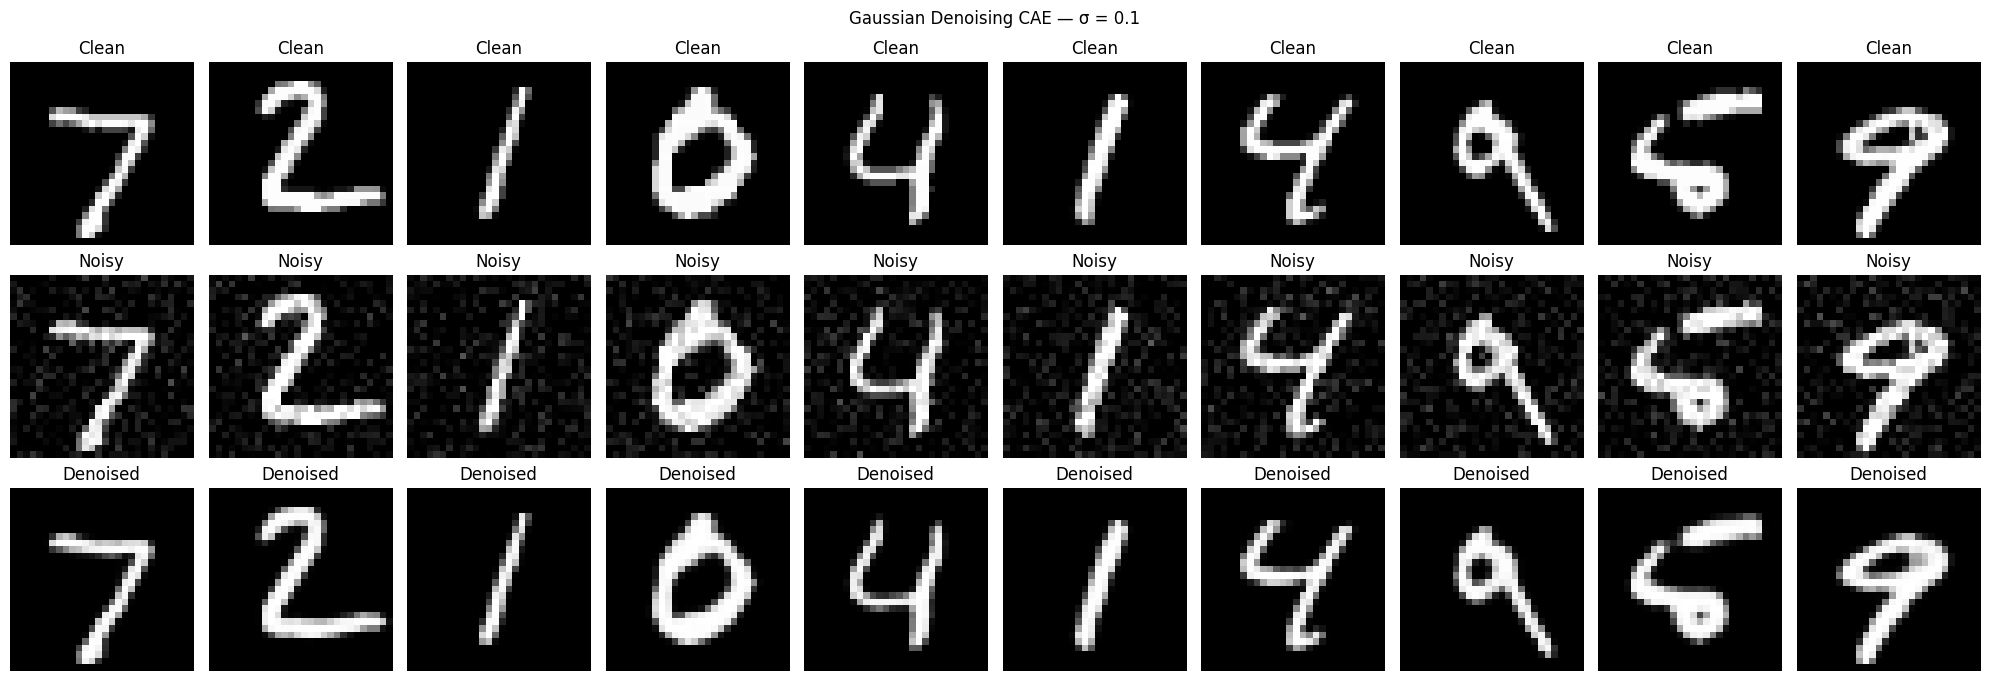



        GAUSSIAN NOISE σ = 0.2
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0701 - val_loss: 0.0692
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0695 - val_loss: 0.0692
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0694 - val_loss: 0.0692
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0694 - val_loss: 0.0691
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0694 - val_loss: 0.0694
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0693 - val_loss: 0.0690
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0693 - val_loss: 0.0690
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0693 - val_loss: 0.0690
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0693 - val_loss: 0.0690
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0692 - val_loss: 0.0690
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0692 - val_loss: 0.0690
Epoch 12/20
469/46

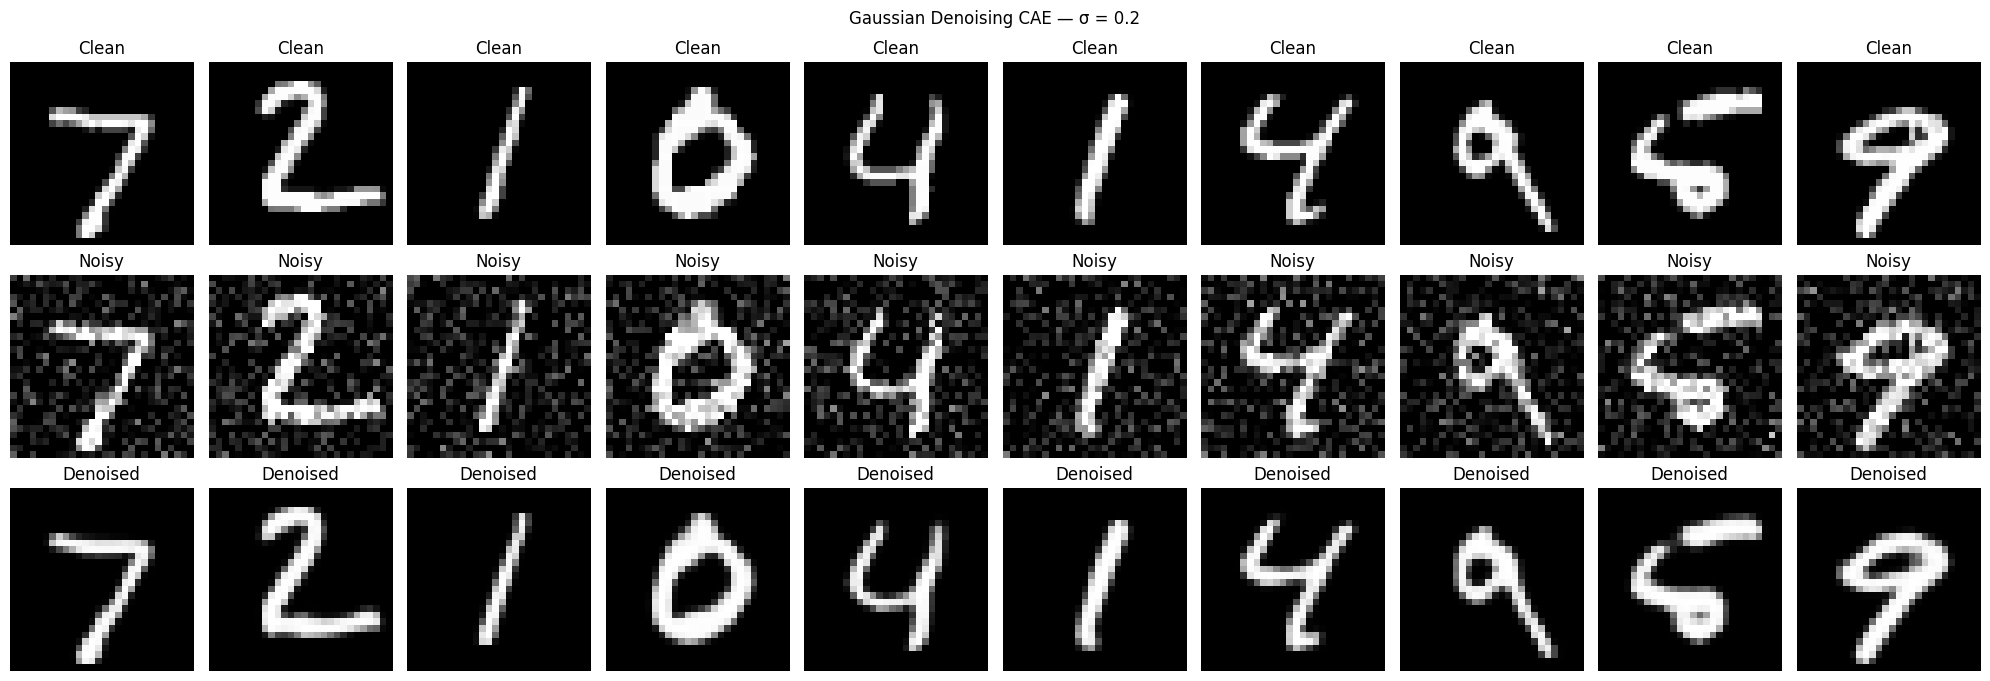



        GAUSSIAN NOISE σ = 0.3
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0760 - val_loss: 0.0753
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0755 - val_loss: 0.0751
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0754 - val_loss: 0.0750
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0754 - val_loss: 0.0751
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0753 - val_loss: 0.0750
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0752 - val_loss: 0.0750
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0752 - val_loss: 0.0750
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0751 - val_loss: 0.0749
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0751 - val_loss: 0.0750
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0751 - val_loss: 0.0750
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0750 - val_loss: 0.0749
Epoch 12/20
469/46

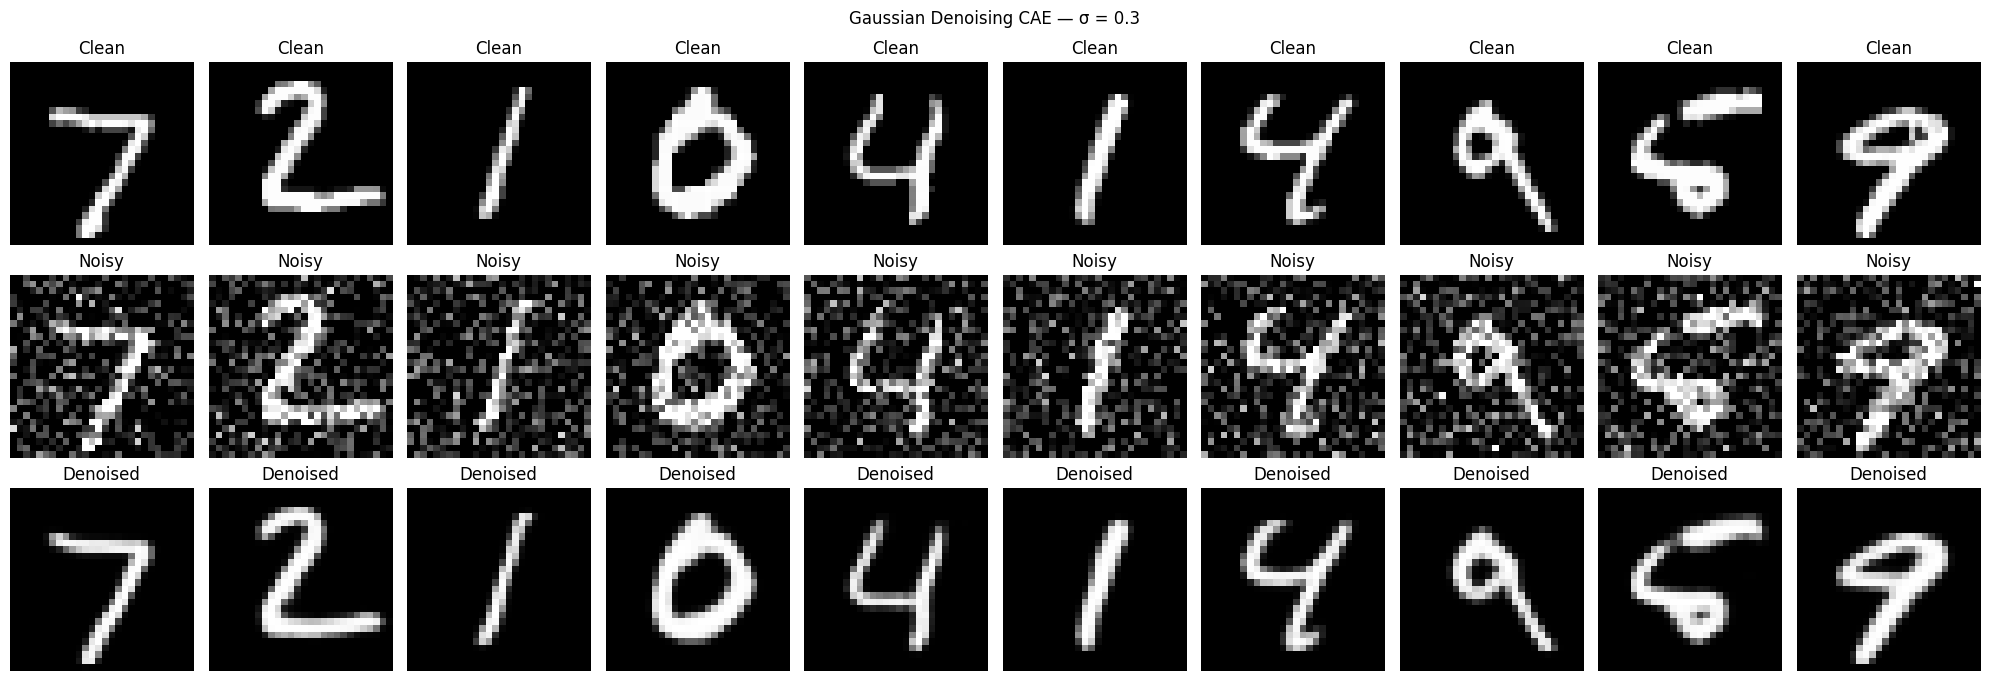



           FINAL GAUSSIAN NOISE RESULTS
 Noise Level      MSE      MAE     SSIM
         0.1 0.001438 0.011571 0.981921
         0.2 0.002695 0.016038 0.965012
         0.3 0.004483 0.020824 0.943820


In [15]:


noise_levels = [0.1, 0.2, 0.3]

results = []



for noise_factor in noise_levels:

    print("\n")
    print("=" * 60)
    print(f"        GAUSSIAN NOISE σ = {noise_factor}")
    print("=" * 60)


    train_noise = np.random.normal(
        0,
        noise_factor,
        x_train_cnn.shape
    )

    test_noise = np.random.normal(
        0,
        noise_factor,
        x_test_cnn.shape
    )


    x_train_noisy = x_train_cnn + train_noise
    x_test_noisy = x_test_cnn + test_noise


    # Keep pixels between 0 and 1
    x_train_noisy = np.clip(
        x_train_noisy,
        0,
        1
    )

    x_test_noisy = np.clip(
        x_test_noisy,
        0,
        1
    )


    denoising_cae = Model(
        conv_autoencoder.input,
        conv_autoencoder.output
    )

    denoising_cae.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )


    history = denoising_cae.fit(
        x_train_noisy,
        x_train_cnn,

        epochs=20,
        batch_size=128,

        validation_data=(
            x_test_noisy,
            x_test_cnn
        ),

        verbose=1
    )


    denoised = denoising_cae.predict(
        x_test_noisy,
        verbose=0
    )

    mse = mean_squared_error(
        x_test_cnn.flatten(),
        denoised.flatten()
    )

    mae = mean_absolute_error(
        x_test_cnn.flatten(),
        denoised.flatten()
    )


    ssim_scores = []

    for i in range(len(x_test_cnn)):

        score = ssim(
            x_test_cnn[i].squeeze(),
            denoised[i].squeeze(),
            data_range=1.0
        )

        ssim_scores.append(score)


    mean_ssim = np.mean(ssim_scores)



    results.append({
        "Noise Level": noise_factor,
        "MSE": mse,
        "MAE": mae,
        "SSIM": mean_ssim
    })


    print("\nResults:")
    print("Noise σ :", noise_factor)
    print("MSE     :", mse)
    print("MAE     :", mae)
    print("SSIM    :", mean_ssim)


    n = 10

    plt.figure(figsize=(20, 7))

    for i in range(n):

        # Clean
        plt.subplot(3, n, i + 1)

        plt.imshow(
            x_test_cnn[i].squeeze(),
            cmap="gray"
        )

        plt.title("Clean")
        plt.axis("off")


        # Noisy
        plt.subplot(3, n, i + 1 + n)

        plt.imshow(
            x_test_noisy[i].squeeze(),
            cmap="gray"
        )

        plt.title("Noisy")
        plt.axis("off")


        # Denoised
        plt.subplot(3, n, i + 1 + 2*n)

        plt.imshow(
            denoised[i].squeeze(),
            cmap="gray"
        )

        plt.title("Denoised")
        plt.axis("off")


    plt.suptitle(
        f"Gaussian Denoising CAE — σ = {noise_factor}"
    )

    plt.tight_layout()
    plt.show()



import pandas as pd

results_df = pd.DataFrame(results)

print("\n")
print("=" * 60)
print("           FINAL GAUSSIAN NOISE RESULTS")
print("=" * 60)

print(results_df.to_string(index=False))

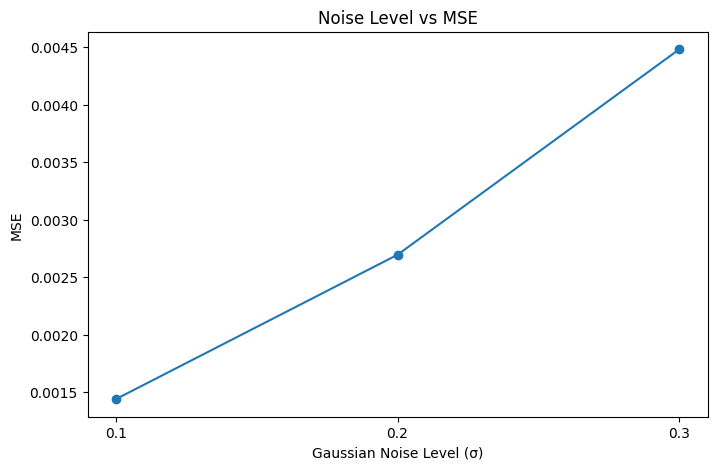

In [16]:


plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Noise Level"],
    results_df["MSE"],
    marker="o"
)

plt.xlabel("Gaussian Noise Level (σ)")
plt.ylabel("MSE")

plt.title("Noise Level vs MSE")

plt.xticks(noise_levels)

plt.show()

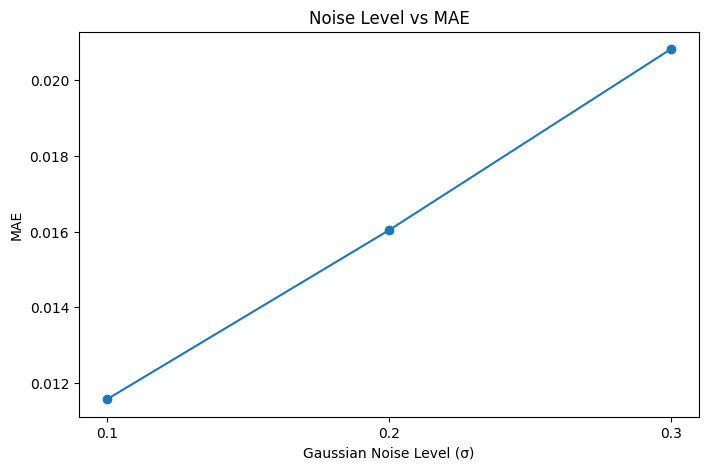

In [17]:


plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Noise Level"],
    results_df["MAE"],
    marker="o"
)

plt.xlabel("Gaussian Noise Level (σ)")
plt.ylabel("MAE")

plt.title("Noise Level vs MAE")

plt.xticks(noise_levels)

plt.show()

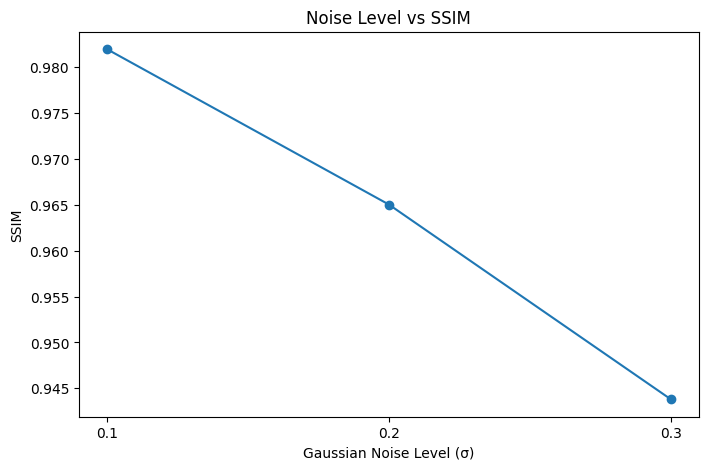

In [18]:

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Noise Level"],
    results_df["SSIM"],
    marker="o"
)

plt.xlabel("Gaussian Noise Level (σ)")
plt.ylabel("SSIM")

plt.title("Noise Level vs SSIM")

plt.xticks(noise_levels)

plt.show()

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.1184 - val_loss: 0.0778
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0762 - val_loss: 0.0737
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0735 - val_loss: 0.0724
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0721 - val_loss: 0.0708
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0710 - val_loss: 0.0701
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0703 - val_loss: 0.0694
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0697 - val_loss: 0.0692
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0692 - val_loss: 0.0685
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0688 - val_loss: 0.0681
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0684 - val_loss: 0.0680
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0681 - val_loss: 0.0676
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/ste

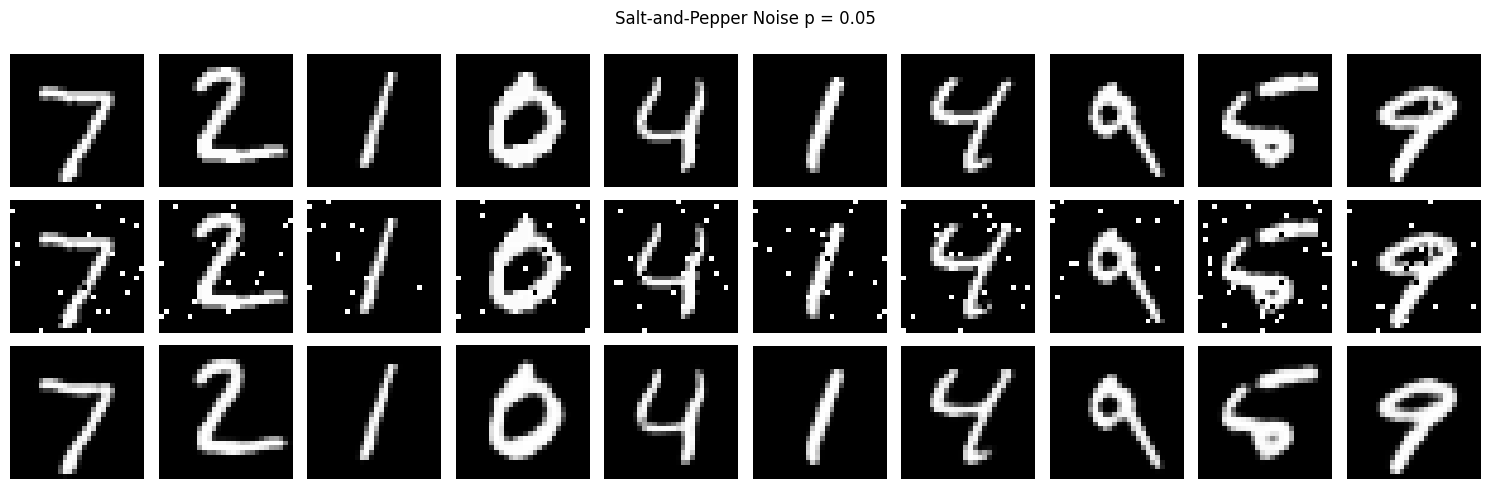

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.1178 - val_loss: 0.0829
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0808 - val_loss: 0.0780
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0776 - val_loss: 0.0768
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0758 - val_loss: 0.0746
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0746 - val_loss: 0.0735
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0737 - val_loss: 0.0727
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0729 - val_loss: 0.0719
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0722 - val_loss: 0.0714
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0716 - val_loss: 0.0709
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0711 - val_loss: 0.0705
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0706 - val_loss: 0.0701
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/ste

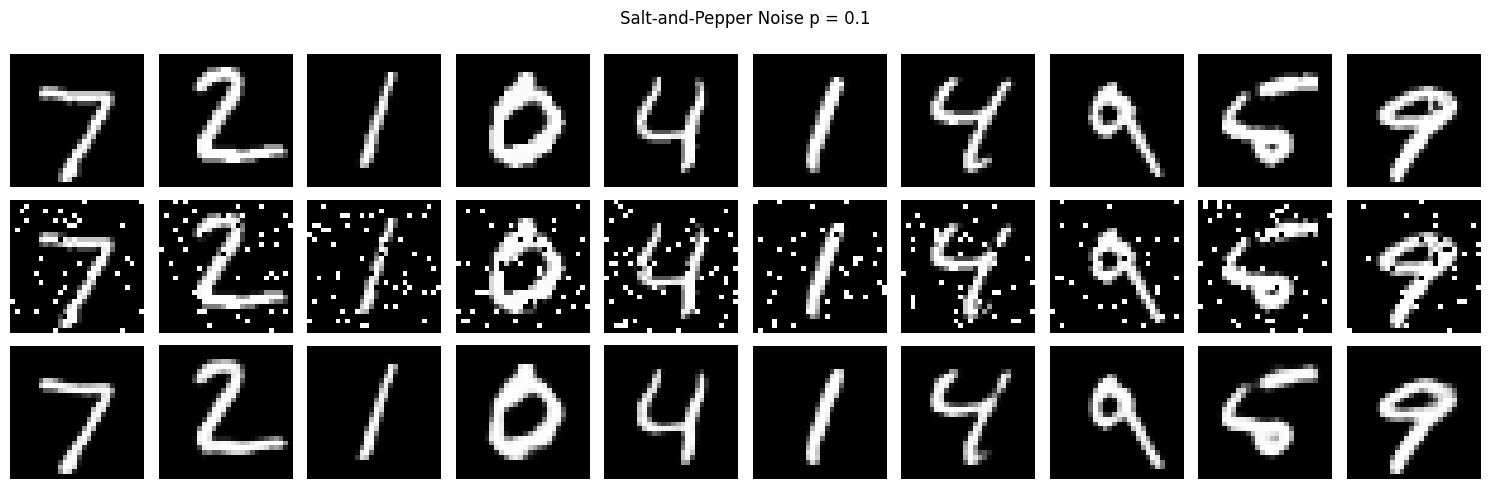

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.1276 - val_loss: 0.0921
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0896 - val_loss: 0.0859
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0851 - val_loss: 0.0828
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0826 - val_loss: 0.0809
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0809 - val_loss: 0.0796
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0796 - val_loss: 0.0786
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0785 - val_loss: 0.0778
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0776 - val_loss: 0.0767
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0769 - val_loss: 0.0761
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0762 - val_loss: 0.0754
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0756 - val_loss: 0.0748
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/ste

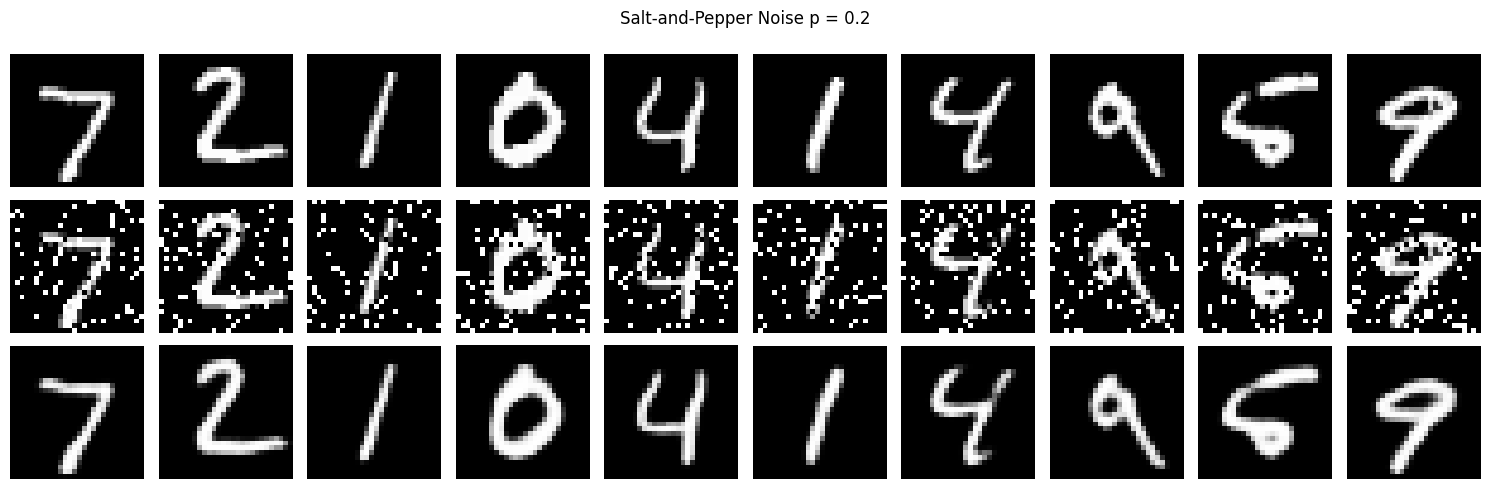


Final Salt-and-Pepper Results


,Noise Level (p),MSE,MAE,SSIM
0,0.05,0.002025,0.013152,0.978309
1,0.10,0.002659,0.015005,0.970740
2,0.20,0.003999,0.018707,0.956615


In [19]:
noise_levels = [0.05, 0.10, 0.20]

results_sp = []

for p in noise_levels:

    # Create noisy training images
    x_train_noisy = x_train_cnn.copy()
    random_matrix = np.random.rand(*x_train_noisy.shape)

    x_train_noisy[random_matrix < p/2] = 0.0       # Pepper
    x_train_noisy[random_matrix > 1 - p/2] = 1.0  # Salt

    # Create noisy test images
    x_test_noisy = x_test_cnn.copy()
    random_matrix = np.random.rand(*x_test_noisy.shape)

    x_test_noisy[random_matrix < p/2] = 0.0
    x_test_noisy[random_matrix > 1 - p/2] = 1.0

    # Build a fresh denoising CAE
    input_layer = Input(shape=(28, 28, 1))

    x = Conv2D(32, (3,3), activation="relu", padding="same")(input_layer)
    x = MaxPooling2D((2,2), padding="same")(x)

    x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2,2), padding="same")(x)

    x = Conv2D(64, (3,3), activation="relu", padding="same")(x)

    x = UpSampling2D((2,2))(x)
    x = Conv2D(32, (3,3), activation="relu", padding="same")(x)

    x = UpSampling2D((2,2))(x)
    output_layer = Conv2D(1, (3,3), activation="sigmoid", padding="same")(x)

    denoising_cae_sp = Model(input_layer, output_layer)

    denoising_cae_sp.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    # Train: noisy input -> clean target
    history_sp = denoising_cae_sp.fit(
        x_train_noisy,
        x_train_cnn,
        epochs=20,
        batch_size=128,
        validation_data=(x_test_noisy, x_test_cnn),
        verbose=1
    )

    # Reconstruction
    denoised_sp = denoising_cae_sp.predict(
        x_test_noisy,
        verbose=0
    )

    # MSE
    mse = mean_squared_error(
        x_test_cnn.flatten(),
        denoised_sp.flatten()
    )

    # MAE
    mae = mean_absolute_error(
        x_test_cnn.flatten(),
        denoised_sp.flatten()
    )

    # SSIM
    ssim_scores = [
        ssim(
            x_test_cnn[i].squeeze(),
            denoised_sp[i].squeeze(),
            data_range=1.0
        )
        for i in range(len(x_test_cnn))
    ]

    mean_ssim = np.mean(ssim_scores)

    results_sp.append({
        "Noise Level (p)": p,
        "MSE": mse,
        "MAE": mae,
        "SSIM": mean_ssim
    })

    print(f"\nSalt-and-Pepper Noise p = {p}")
    print(f"MSE  : {mse:.6f}")
    print(f"MAE  : {mae:.6f}")
    print(f"SSIM : {mean_ssim:.6f}")

    # Show examples
    fig, axes = plt.subplots(3, 10, figsize=(15, 5))

    for i in range(10):

        axes[0, i].imshow(x_test_cnn[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")

        axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")

        axes[2, i].imshow(denoised_sp[i].squeeze(), cmap="gray")
        axes[2, i].axis("off")

    axes[0, 0].set_ylabel("Clean")
    axes[1, 0].set_ylabel("Noisy")
    axes[2, 0].set_ylabel("Denoised")

    plt.suptitle(f"Salt-and-Pepper Noise p = {p}")
    plt.tight_layout()
    plt.show()


results_sp_df = pd.DataFrame(results_sp)

print("\nFinal Salt-and-Pepper Results")
display(results_sp_df)

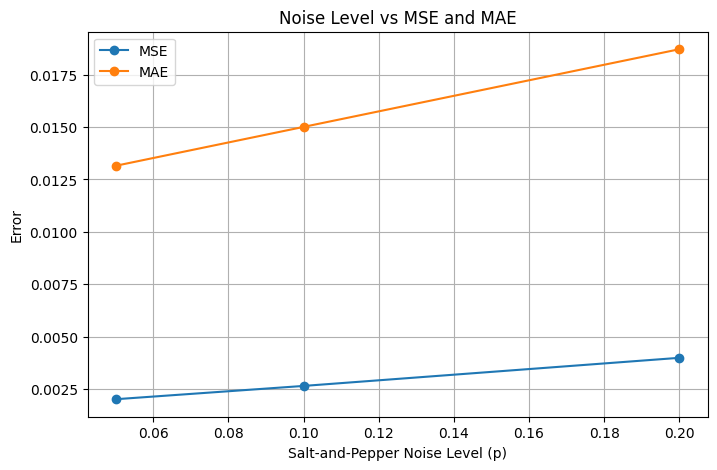

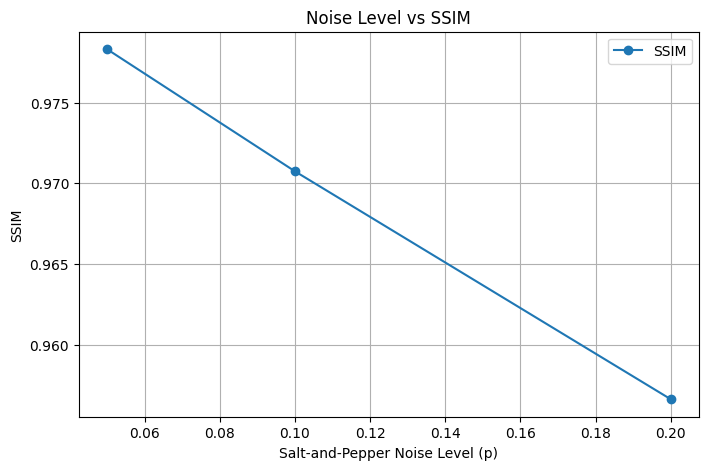

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    results_sp_df["Noise Level (p)"],
    results_sp_df["MSE"],
    marker="o",
    label="MSE"
)

plt.plot(
    results_sp_df["Noise Level (p)"],
    results_sp_df["MAE"],
    marker="o",
    label="MAE"
)

plt.xlabel("Salt-and-Pepper Noise Level (p)")
plt.ylabel("Error")
plt.title("Noise Level vs MSE and MAE")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(8,5))

plt.plot(
    results_sp_df["Noise Level (p)"],
    results_sp_df["SSIM"],
    marker="o",
    label="SSIM"
)

plt.xlabel("Salt-and-Pepper Noise Level (p)")
plt.ylabel("SSIM")
plt.title("Noise Level vs SSIM")
plt.legend()
plt.grid()
plt.show()

# Part 2 — Missing sections (VAE, latent-dimension study, consolidated results, inferences)

Everything above this line is your original work (FC-AE, CAE, comparison, Gaussian + salt-and-pepper denoising).
The cells below add what Experiment 7 still needs: **VAE (Sec. 15–20), VAE metrics table, latent-dimension study (Sec. 27 / Plot 10), consolidated table (Sec. 25) with time, and written inferences / discussion answers.**

They only rely on `x_train`, `x_test`, `y_test` from your first cell and create new variable names, so nothing above is overwritten.

In [21]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, ops
from scipy.stats import norm
from skimage.metrics import structural_similarity as ssim

np.random.seed(42)
tf.random.set_seed(42)

EPOCHS     = 20     # FC-AE / CAE / DCAE / latent study
VAE_EPOCHS = 30     # VAE
BATCH      = 128

# fresh copies of the data (float32, [0,1])
x_tr      = x_train.reshape(-1, 28, 28, 1).astype("float32")
x_te      = x_test.reshape(-1, 28, 28, 1).astype("float32")
x_tr_flat = x_tr.reshape(-1, 784)
x_te_flat = x_te.reshape(-1, 784)

print("Train:", x_tr.shape, " Test:", x_te.shape, " Labels:", y_test.shape)


def evaluate_recon(original, reconstructed):
    """MSE, MAE and mean SSIM between two image arrays (any shape with N images)."""
    o = np.asarray(original).reshape(-1, 28, 28)
    r = np.asarray(reconstructed).reshape(-1, 28, 28)
    mse_ = float(np.mean((o - r) ** 2))
    mae_ = float(np.mean(np.abs(o - r)))
    ssim_ = float(np.mean([ssim(o[i], r[i], data_range=1.0) for i in range(len(o))]))
    return mse_, mae_, ssim_

Train: (60000, 28, 28, 1)  Test: (10000, 28, 28, 1)  Labels: (10000,)


## 15–17. Variational Autoencoder (latent dimension = 2)

Encoder: `28×28×1 → Conv → Conv → Flatten → Dense → (μ, log σ²) ∈ ℝ²` → sampling `z = μ + σ ⊙ ε`, `ε ~ N(0, I)`  
Decoder: `z → Dense → Reshape → Conv2DTranspose ×3 → 28×28×1`  
Loss: `L_VAE = L_rec + L_KL`, where `L_rec` is the binary cross-entropy **summed over the 784 pixels** (averaged over the batch) and `L_KL = -½ Σ(1 + log σ² − μ² − σ²)`.

In [22]:

latent_dim = 2


class Sampling(layers.Layer):
    """z = mu + sigma * epsilon,  epsilon ~ N(0, I)"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim   = ops.shape(z_mean)[1]
        eps   = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * eps


# ---------- Encoder ----------
enc_in = keras.Input(shape=(28, 28, 1))
h = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(enc_in)   # 14x14x32
h = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(h)        # 7x7x64
h = layers.Flatten()(h)
h = layers.Dense(16, activation="relu")(h)
z_mean    = layers.Dense(latent_dim, name="z_mean")(h)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)
z         = Sampling(name="z")([z_mean, z_log_var])
vae_encoder = keras.Model(enc_in, [z_mean, z_log_var, z], name="vae_encoder")

# ---------- Decoder ----------
dec_in = keras.Input(shape=(latent_dim,))
d = layers.Dense(7 * 7 * 64, activation="relu")(dec_in)
d = layers.Reshape((7, 7, 64))(d)
d = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(d)   # 14x14
d = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(d)   # 28x28
dec_out = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(d)
vae_decoder = keras.Model(dec_in, dec_out, name="vae_decoder")

vae_encoder.summary()
vae_decoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ============================================================
# VAE — MODEL WITH  L_rec + L_KL
# ============================================================
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_loss_tracker   = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.rec_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        _, _, z = self.encoder(inputs)
        return self.decoder(z)

    def _compute_losses(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        recon = self.decoder(z)

        # reconstruction loss: BCE summed over pixels, averaged over batch
        rec = ops.mean(
            ops.sum(keras.losses.binary_crossentropy(data, recon), axis=(1, 2))
        )
        # KL( q(z|x) || N(0, I) ), summed over latent dims, averaged over batch
        kl = -0.5 * ops.mean(
            ops.sum(1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var), axis=1)
        )
        return rec + kl, rec, kl

    def _update(self, total, rec, kl):
        self.total_loss_tracker.update_state(total)
        self.rec_loss_tracker.update_state(rec)
        self.kl_loss_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        if isinstance(data, (tuple, list)):
            data = data[0]
        with tf.GradientTape() as tape:
            total, rec, kl = self._compute_losses(data)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._update(total, rec, kl)

    def test_step(self, data):
        if isinstance(data, (tuple, list)):
            data = data[0]
        total, rec, kl = self._compute_losses(data)
        return self._update(total, rec, kl)


vae = VAE(vae_encoder, vae_decoder, name="vae")
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

t0 = time.time()
history_vae = vae.fit(
    x_tr,
    epochs=VAE_EPOCHS,
    batch_size=BATCH,
    validation_data=(x_te,),
    verbose=1
)
vae_time   = time.time() - t0
vae_params = vae_encoder.count_params() + vae_decoder.count_params()
print(f"\nVAE training time: {vae_time:.1f} s   |   parameters: {vae_params:,}")

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - kl_loss: 2.9237 - loss: 213.8260 - reconstruction_loss: 210.9024 - val_kl_loss: 5.2291 - val_loss: 183.3334 - val_reconstruction_loss: 178.1043
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.1040 - loss: 176.1609 - reconstruction_loss: 171.0568 - val_kl_loss: 5.1389 - val_loss: 171.2510 - val_reconstruction_loss: 166.1121
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.2704 - loss: 167.2664 - reconstruction_loss: 161.9961 - val_kl_loss: 5.3916 - val_loss: 164.4104 - val_reconstruction_loss: 159.0189
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 5.4627 - loss: 162.3974 - reconstruction_loss: 156.9346 - val_kl_loss: 5.5220 - val_loss: 160.7893 - val_reconstruction_loss: 155.2673
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.5764 - loss: 159.8315 - reconstruction_loss: 154.2552 - val_kl_loss: 5.6539 - val_loss: 158.8760 - val_reconstruction_loss: 153.2221
Epoch 6/

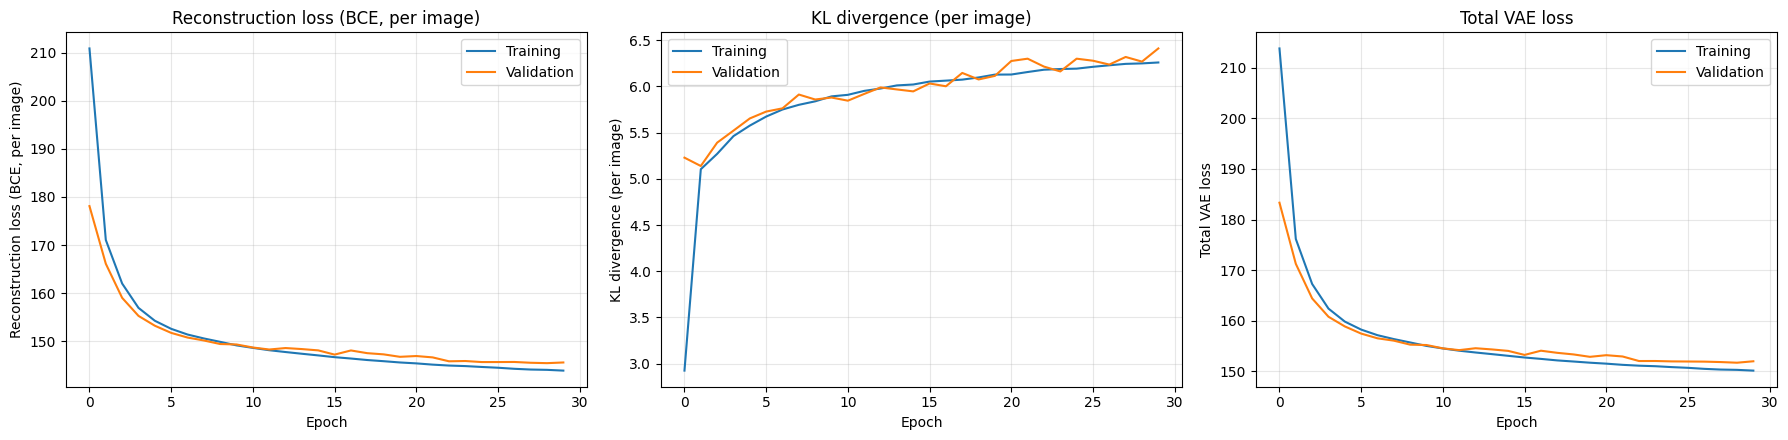

In [24]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, key, title in zip(
    axes,
    ["reconstruction_loss", "kl_loss", "loss"],
    ["Reconstruction loss (BCE, per image)", "KL divergence (per image)", "Total VAE loss"]
):
    ax.plot(history_vae.history[key], label="Training")
    ax.plot(history_vae.history["val_" + key], label="Validation")
    ax.set_xlabel("Epoch"); ax.set_ylabel(title); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:

vae_test = vae.evaluate(x_te, batch_size=BATCH, return_dict=True, verbose=0)

# Reconstruction quality: decode the MEAN of q(z|x) (deterministic reconstruction)
z_mean_te, z_logvar_te, _ = vae_encoder.predict(x_te, batch_size=BATCH, verbose=0)
vae_recon = vae_decoder.predict(z_mean_te, batch_size=BATCH, verbose=0)

vae_mse, vae_mae, vae_ssim = evaluate_recon(x_te, vae_recon)

vae_table = pd.DataFrame({
    "VAE Metric": ["Reconstruction Loss", "KL Loss", "Total Loss", "Test MSE", "Test MAE", "Mean SSIM"],
    "Value": [vae_test["reconstruction_loss"], vae_test["kl_loss"], vae_test["loss"],
              vae_mse, vae_mae, vae_ssim]
})
print(vae_table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

         VAE Metric      Value
Reconstruction Loss 145.650055
            KL Loss   6.411634
         Total Loss 152.061691
           Test MSE   0.041470
           Test MAE   0.098829
          Mean SSIM   0.538616


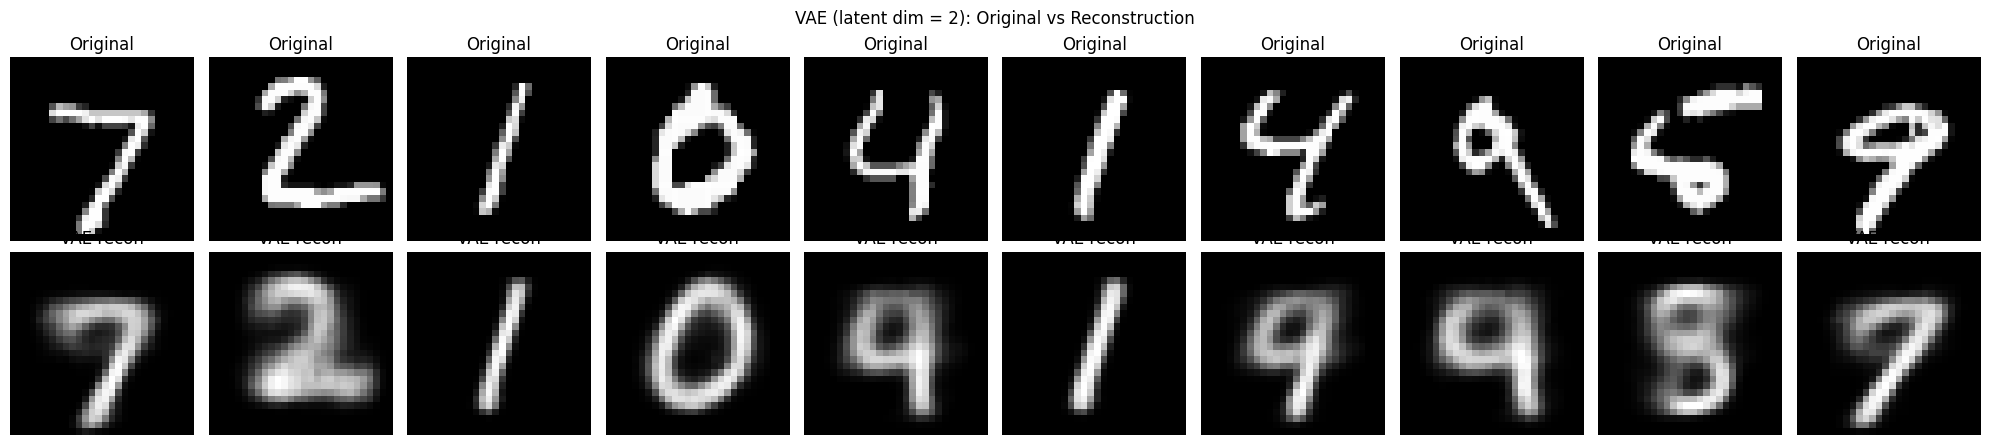

In [26]:

n = 10
plt.figure(figsize=(20, 4.5))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_te[i].squeeze(), cmap="gray"); plt.title("Original"); plt.axis("off")
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(vae_recon[i].squeeze(), cmap="gray"); plt.title("VAE recon"); plt.axis("off")
plt.suptitle("VAE (latent dim = 2): Original vs Reconstruction")
plt.tight_layout(); plt.show()

## 18. Plot 6 — VAE latent space (labels used only for colouring)

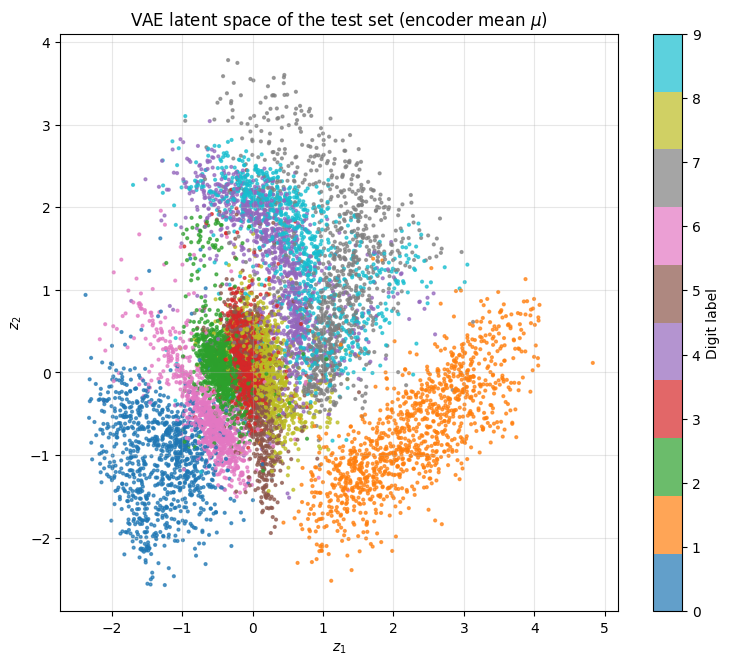

 digit  mean_z1  mean_z2  std_z1  std_z2
     0   -1.281   -1.017   0.464   0.585
     1    2.242   -0.707   0.843   0.680
     2   -0.446    0.126   0.222   0.432
     3   -0.079    0.171   0.175   0.392
     4    0.306    1.289   0.601   0.773
     5    0.058   -0.173   0.240   0.641
     6   -0.635   -0.478   0.390   0.521
     7    1.032    1.203   0.579   1.000
     8    0.191    0.034   0.283   0.452
     9    0.588    1.418   0.716   0.782

Overall latent mean: [0.233 0.186]  std: [1.074 1.046]


In [27]:

plt.figure(figsize=(9, 7.5))
sc = plt.scatter(z_mean_te[:, 0], z_mean_te[:, 1], c=y_test, cmap="tab10", s=4, alpha=0.7)
cbar = plt.colorbar(sc, ticks=range(10)); cbar.set_label("Digit label")
plt.xlabel("$z_1$"); plt.ylabel("$z_2$")
plt.title("VAE latent space of the test set (encoder mean $\\mu$)")
plt.grid(alpha=0.3)
plt.show()

# cluster centres and spread per digit (numeric support for the inference)
centres = pd.DataFrame({
    "digit": range(10),
    "mean_z1": [z_mean_te[y_test == d, 0].mean() for d in range(10)],
    "mean_z2": [z_mean_te[y_test == d, 1].mean() for d in range(10)],
    "std_z1":  [z_mean_te[y_test == d, 0].std()  for d in range(10)],
    "std_z2":  [z_mean_te[y_test == d, 1].std()  for d in range(10)],
})
print(centres.round(3).to_string(index=False))
print("\nOverall latent mean:", z_mean_te.mean(axis=0).round(3), " std:", z_mean_te.std(axis=0).round(3))

## 19. Plot 7 — Randomly generated images, z ~ N(0, I)

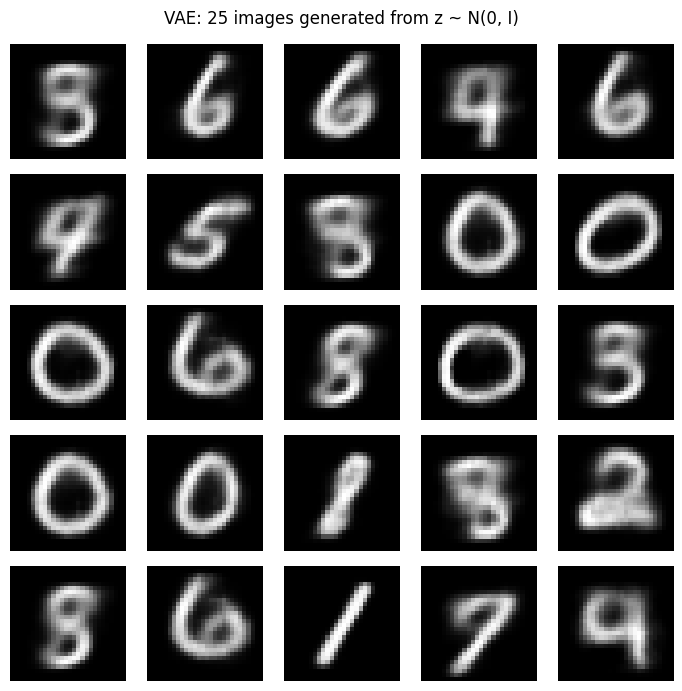

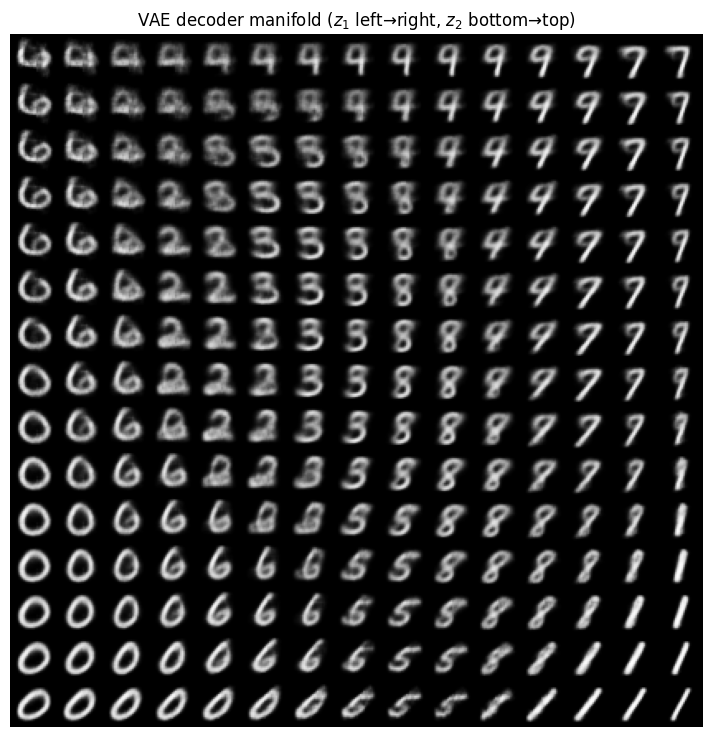

In [28]:

rng = np.random.default_rng(7)
z_random  = rng.standard_normal((25, latent_dim)).astype("float32")
generated = vae_decoder.predict(z_random, verbose=0)

plt.figure(figsize=(7, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(generated[i].squeeze(), cmap="gray"); plt.axis("off")
plt.suptitle("VAE: 25 images generated from z ~ N(0, I)")
plt.tight_layout(); plt.show()


# Extra (Additional Exercise 7): 15 x 15 manifold over the latent plane
grid_n = 15
u = norm.ppf(np.linspace(0.05, 0.95, grid_n))        # inverse-CDF spacing of N(0,1)
canvas = np.zeros((28 * grid_n, 28 * grid_n))
for r, z2 in enumerate(u[::-1]):
    for c, z1 in enumerate(u):
        img = vae_decoder.predict(np.array([[z1, z2]], dtype="float32"), verbose=0)[0, :, :, 0]
        canvas[r * 28:(r + 1) * 28, c * 28:(c + 1) * 28] = img

plt.figure(figsize=(9, 9))
plt.imshow(canvas, cmap="gray"); plt.axis("off")
plt.title("VAE decoder manifold ($z_1$ left→right, $z_2$ bottom→top)")
plt.show()

## 20. Plot 8 — Latent-space interpolation

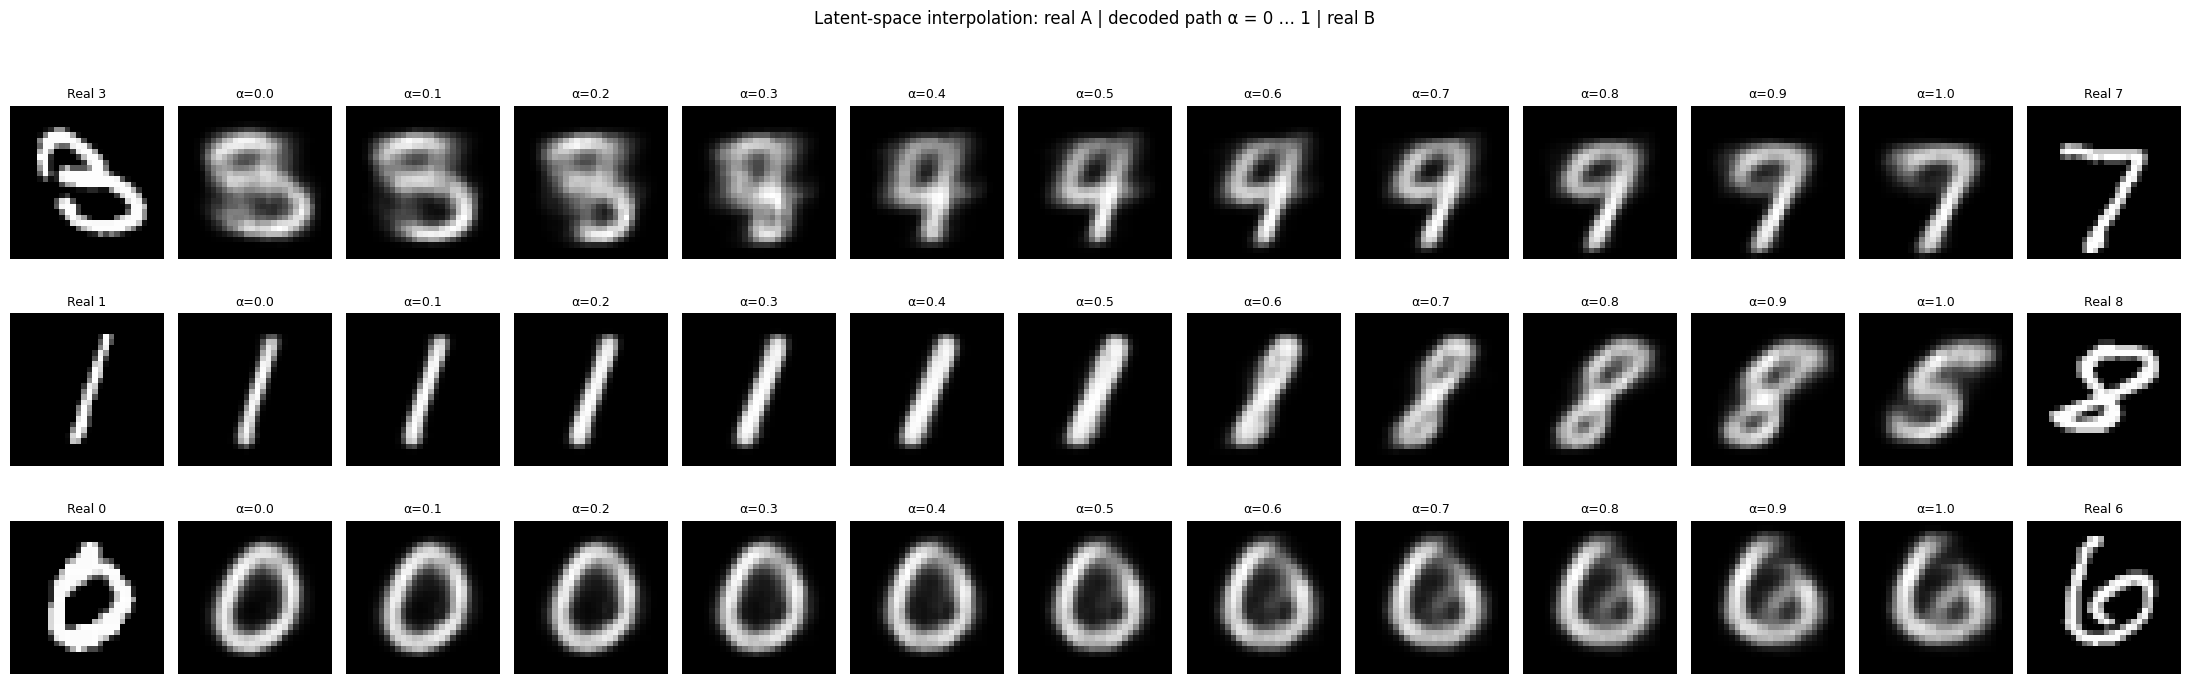

In [29]:

def interpolate(digit_a, digit_b, row_title):
    idx_a = int(np.where(y_test == digit_a)[0][0])
    idx_b = int(np.where(y_test == digit_b)[0][0])
    z_a, z_b = z_mean_te[idx_a], z_mean_te[idx_b]

    alphas = np.round(np.arange(0, 1.01, 0.1), 1)
    z_path = np.array([(1 - a) * z_a + a * z_b for a in alphas], dtype="float32")
    decoded = vae_decoder.predict(z_path, verbose=0)
    return idx_a, idx_b, alphas, decoded

pairs = [(3, 7), (1, 8), (0, 6)]
fig, axes = plt.subplots(len(pairs), 13, figsize=(22, 2 * len(pairs) + 1))

for row, (da, db) in enumerate(pairs):
    ia, ib, alphas, decoded = interpolate(da, db, "")
    axes[row, 0].imshow(x_te[ia].squeeze(), cmap="gray");  axes[row, 0].set_title(f"Real {da}", fontsize=9)
    for k, a in enumerate(alphas):
        axes[row, k + 1].imshow(decoded[k].squeeze(), cmap="gray")
        axes[row, k + 1].set_title(f"α={a}", fontsize=9)
    axes[row, 12].imshow(x_te[ib].squeeze(), cmap="gray"); axes[row, 12].set_title(f"Real {db}", fontsize=9)
    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Latent-space interpolation: real A | decoded path α = 0 … 1 | real B", y=1.02)
plt.tight_layout(); plt.show()

## 27. Additional latent-dimension study (Plot 10)

The basic fully connected autoencoder (784-128-32-**d<sub>z</sub>**-32-128-784) is retrained for d<sub>z</sub> ∈ {2, 8, 16, 32}.

In [30]:

def build_fc_ae(dz):
    inp = keras.Input(shape=(784,))
    h = layers.Dense(128, activation="relu")(inp)
    h = layers.Dense(32,  activation="relu")(h)
    z = layers.Dense(dz,  activation="relu")(h)
    h = layers.Dense(32,  activation="relu")(z)
    h = layers.Dense(128, activation="relu")(h)
    out = layers.Dense(784, activation="sigmoid")(h)
    m = keras.Model(inp, out, name=f"fc_ae_dz{dz}")
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    return m


latent_rows = []
fc_recons_by_dz = {}

for dz in [2, 8, 16, 32]:
    keras.utils.set_random_seed(42)
    m = build_fc_ae(dz)

    t0 = time.time()
    m.fit(x_tr_flat, x_tr_flat, epochs=EPOCHS, batch_size=BATCH,
          validation_data=(x_te_flat, x_te_flat), verbose=0)
    train_time = time.time() - t0

    rec = m.predict(x_te_flat, batch_size=BATCH, verbose=0)
    fc_recons_by_dz[dz] = rec
    mse_, mae_, ssim_ = evaluate_recon(x_te_flat, rec)

    latent_rows.append({"Latent Dimension": dz, "MSE": mse_, "MAE": mae_,
                        "SSIM": ssim_, "Parameters": m.count_params(), "Time (s)": train_time})
    print(f"dz={dz:>2}  MSE={mse_:.6f}  MAE={mae_:.6f}  SSIM={ssim_:.4f}  params={m.count_params():,}  time={train_time:.0f}s")

latent_df = pd.DataFrame(latent_rows)
print("\n", latent_df.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

dz= 2  MSE=0.040652  MAE=0.096101  SSIM=0.5574  params=210,130  time=39s
dz= 8  MSE=0.024273  MAE=0.063224  SSIM=0.7303  params=210,520  time=36s
dz=16  MSE=0.012752  MAE=0.039208  SSIM=0.8582  params=211,040  time=35s
dz=32  MSE=0.009995  MAE=0.033348  SSIM=0.8893  params=212,080  time=36s

  Latent Dimension      MSE      MAE     SSIM  Parameters  Time (s)
                2 0.040652 0.096101 0.557413      210130 38.764880
                8 0.024273 0.063224 0.730260      210520 35.569061
               16 0.012752 0.039208 0.858184      211040 35.377522
               32 0.009995 0.033348 0.889279      212080 36.182787


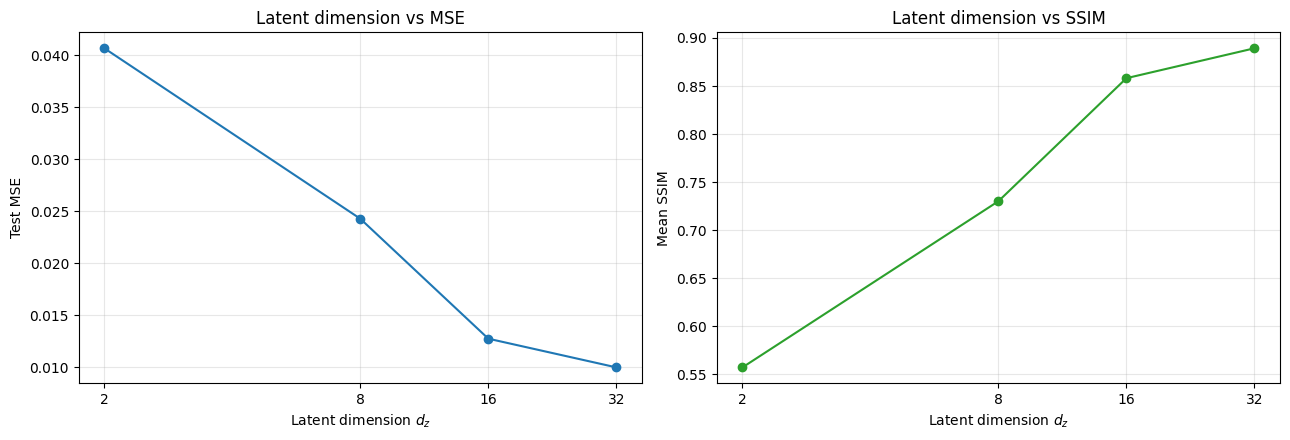

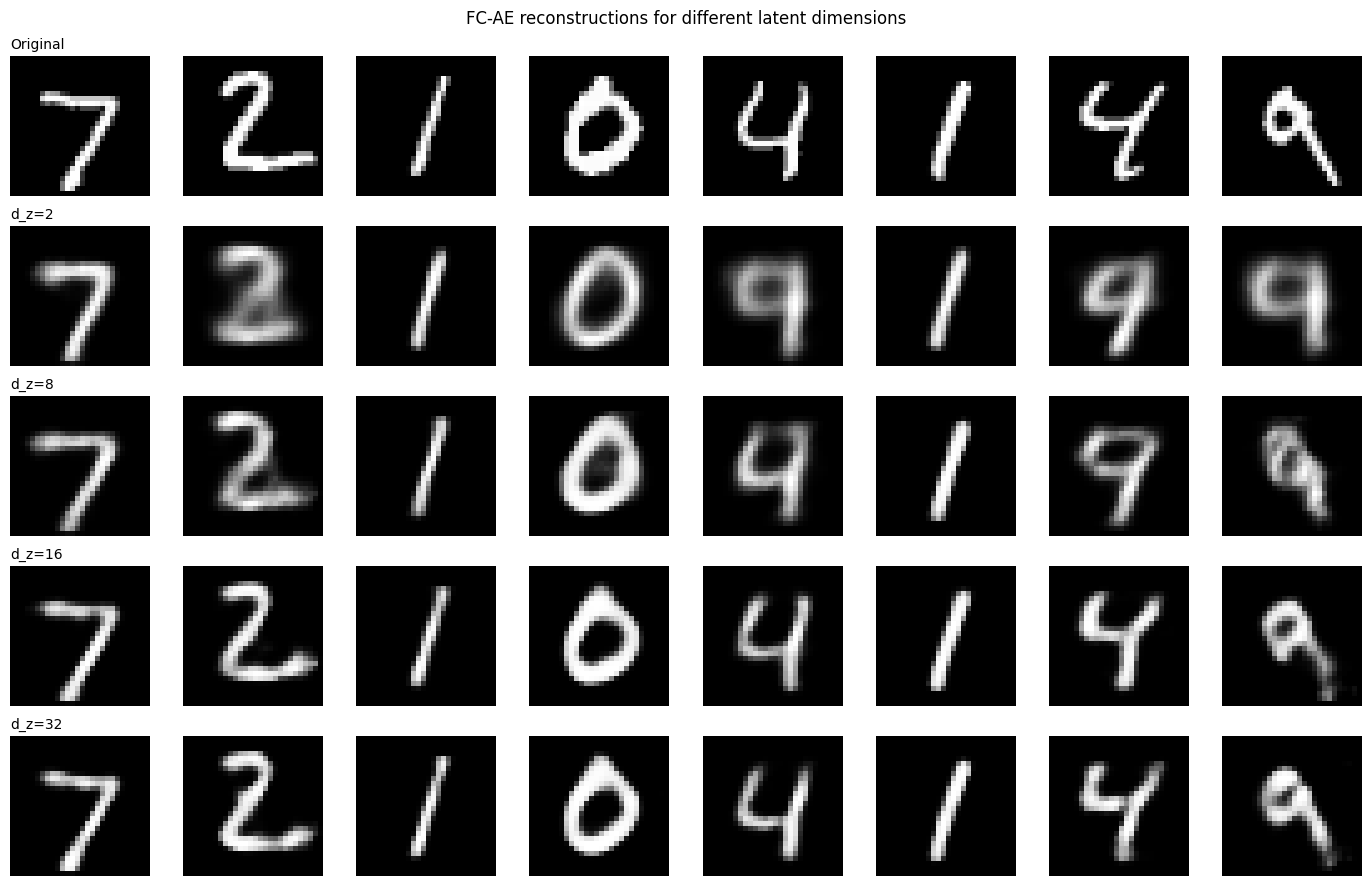

In [31]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(latent_df["Latent Dimension"], latent_df["MSE"], marker="o")
axes[0].set_xscale("log", base=2); axes[0].set_xticks(latent_df["Latent Dimension"])
axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[0].set_xlabel("Latent dimension $d_z$"); axes[0].set_ylabel("Test MSE")
axes[0].set_title("Latent dimension vs MSE"); axes[0].grid(alpha=0.3)

axes[1].plot(latent_df["Latent Dimension"], latent_df["SSIM"], marker="o", color="tab:green")
axes[1].set_xscale("log", base=2); axes[1].set_xticks(latent_df["Latent Dimension"])
axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[1].set_xlabel("Latent dimension $d_z$"); axes[1].set_ylabel("Mean SSIM")
axes[1].set_title("Latent dimension vs SSIM"); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# visual: same 8 digits for every d_z
n = 8
fig, axes = plt.subplots(5, n, figsize=(14, 9))
for j in range(n):
    axes[0, j].imshow(x_te[j].squeeze(), cmap="gray"); axes[0, j].axis("off")
for r, dz in enumerate([2, 8, 16, 32], start=1):
    for j in range(n):
        axes[r, j].imshow(fc_recons_by_dz[dz][j].reshape(28, 28), cmap="gray"); axes[r, j].axis("off")
    axes[r, 0].set_title(f"d_z={dz}", fontsize=10, loc="left")
axes[0, 0].set_title("Original", fontsize=10, loc="left")
plt.suptitle("FC-AE reconstructions for different latent dimensions")
plt.tight_layout(); plt.show()

## 25. Consolidated results (Section 21 / 25 tables)

The FC-AE row comes from the d<sub>z</sub> = 16 run above. The CAE and the denoising CAE (Gaussian σ = 0.2) are trained **fresh** here (independent weights) so that parameters and training time are measured for each model. The denoising model is evaluated on noisy test images against the clean targets.

In [32]:
# ============================================================
# CONSOLIDATED RESULTS TABLE
# ============================================================
def build_cae():
    inp = keras.Input(shape=(28, 28, 1))
    h = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    h = layers.MaxPooling2D(2, padding="same")(h)
    h = layers.Conv2D(64, 3, activation="relu", padding="same")(h)
    h = layers.MaxPooling2D(2, padding="same")(h)
    h = layers.Conv2D(64, 3, activation="relu", padding="same")(h)
    h = layers.UpSampling2D(2)(h)
    h = layers.Conv2D(32, 3, activation="relu", padding="same")(h)
    h = layers.UpSampling2D(2)(h)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(h)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    return m


# ---- CAE (fresh) ----
keras.utils.set_random_seed(42)
cae_new = build_cae()
t0 = time.time()
cae_new.fit(x_tr, x_tr, epochs=EPOCHS, batch_size=BATCH, validation_data=(x_te, x_te), verbose=0)
cae_time = time.time() - t0
cae_rec = cae_new.predict(x_te, batch_size=BATCH, verbose=0)
cae_m = evaluate_recon(x_te, cae_rec)

# ---- Denoising CAE, Gaussian sigma = 0.2 (fresh) ----
sigma = 0.2
rng = np.random.default_rng(0)
x_tr_noisy = np.clip(x_tr + rng.normal(0, sigma, x_tr.shape), 0, 1).astype("float32")
x_te_noisy = np.clip(x_te + rng.normal(0, sigma, x_te.shape), 0, 1).astype("float32")

keras.utils.set_random_seed(42)
dcae_new = build_cae()
t0 = time.time()
dcae_new.fit(x_tr_noisy, x_tr, epochs=EPOCHS, batch_size=BATCH,
             validation_data=(x_te_noisy, x_te), verbose=0)
dcae_time = time.time() - t0
dcae_rec = dcae_new.predict(x_te_noisy, batch_size=BATCH, verbose=0)
dcae_m = evaluate_recon(x_te, dcae_rec)

# ---- FC-AE row = latent study, dz = 16 ----
fc_row = latent_df[latent_df["Latent Dimension"] == 16].iloc[0]

consolidated = pd.DataFrame([
    {"Model": "FC Autoencoder (dz=16)",  "MSE": fc_row["MSE"], "MAE": fc_row["MAE"], "SSIM": fc_row["SSIM"],
     "Parameters": int(fc_row["Parameters"]), "Time (s)": fc_row["Time (s)"]},
    {"Model": "Conv. Autoencoder",       "MSE": cae_m[0], "MAE": cae_m[1], "SSIM": cae_m[2],
     "Parameters": cae_new.count_params(),  "Time (s)": cae_time},
    {"Model": "Denoising CAE (σ=0.2)",   "MSE": dcae_m[0], "MAE": dcae_m[1], "SSIM": dcae_m[2],
     "Parameters": dcae_new.count_params(), "Time (s)": dcae_time},
    {"Model": "VAE (dz=2)",              "MSE": vae_mse, "MAE": vae_mae, "SSIM": vae_ssim,
     "Parameters": vae_params, "Time (s)": vae_time},
])

print("=" * 90)
print("CONSOLIDATED RESULTS")
print("=" * 90)
print(consolidated.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

print("\nVAE loss terms (test set):")
print(vae_table.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

CONSOLIDATED RESULTS
                 Model      MSE      MAE     SSIM  Parameters   Time (s)
FC Autoencoder (dz=16) 0.012752 0.039208 0.858184      211040  35.377522
     Conv. Autoencoder 0.001011 0.009433 0.990356       74497  75.913417
 Denoising CAE (σ=0.2) 0.002956 0.016800 0.962952       74497  76.333828
            VAE (dz=2) 0.041470 0.098829 0.538616      134165 114.843245

VAE loss terms (test set):
         VAE Metric    Value
Reconstruction Loss 145.6501
            KL Loss   6.4116
         Total Loss 152.0617
           Test MSE   0.0415
           Test MAE   0.0988
          Mean SSIM   0.5386


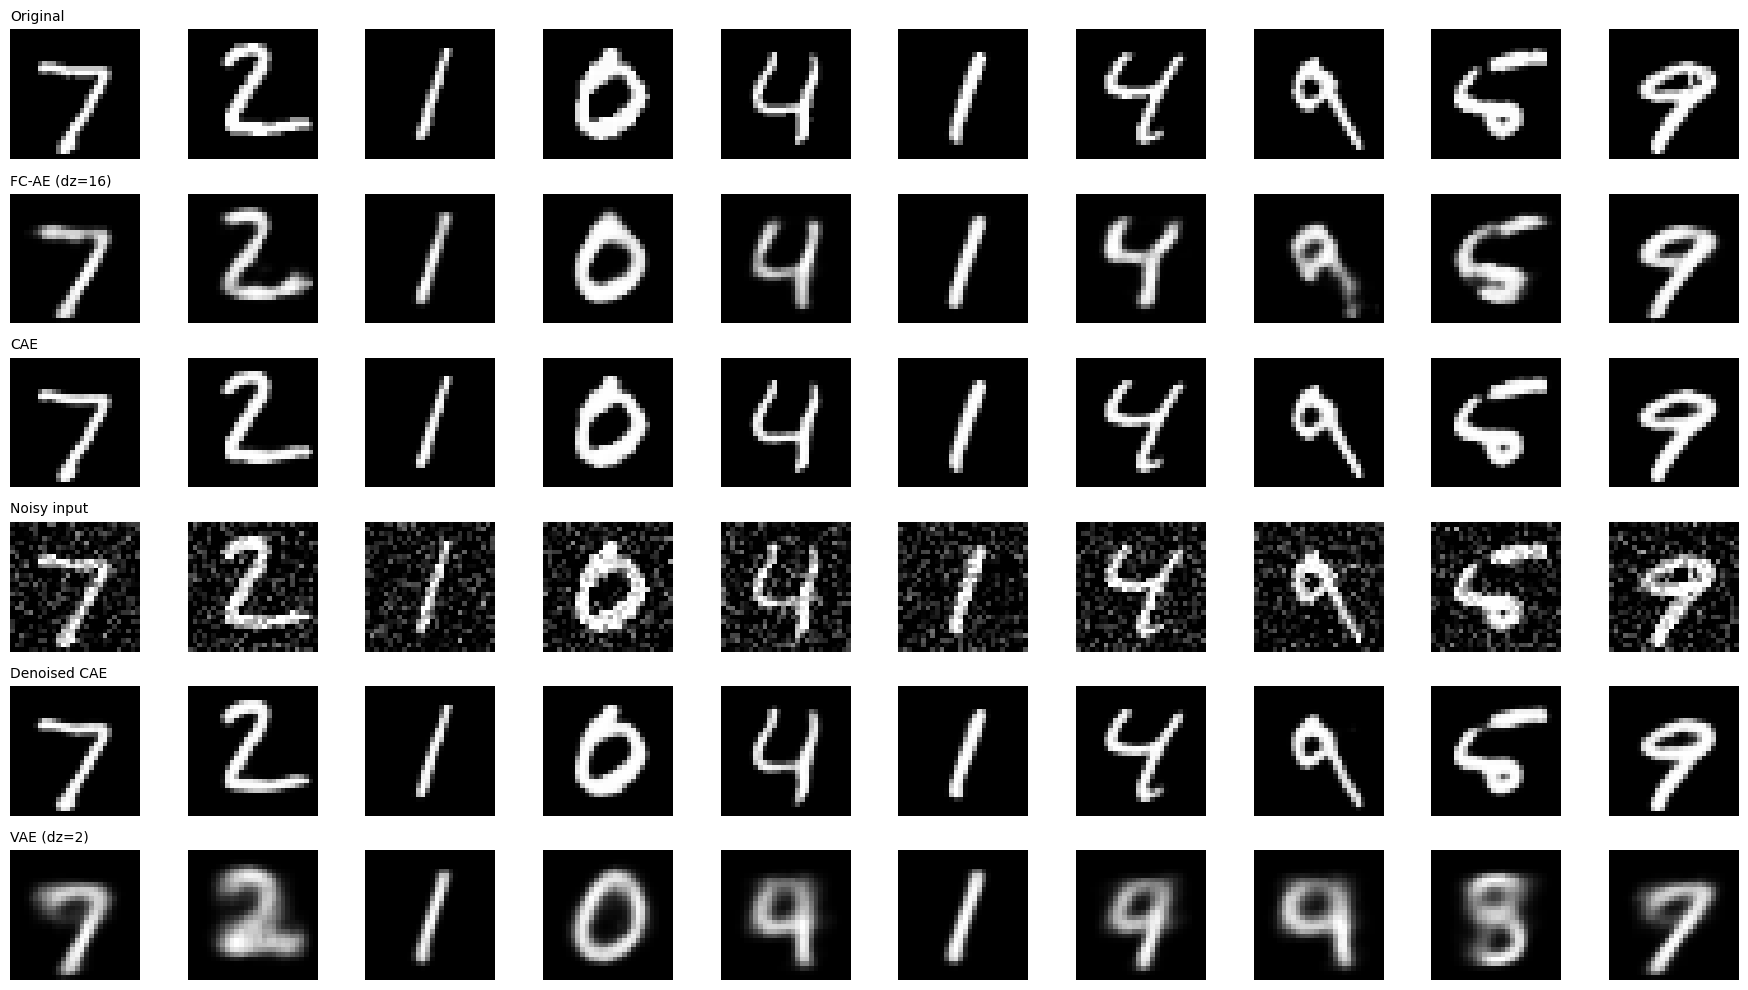

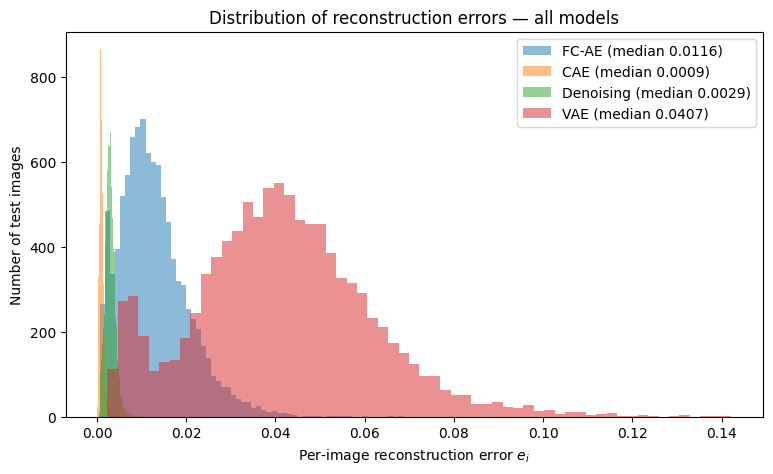

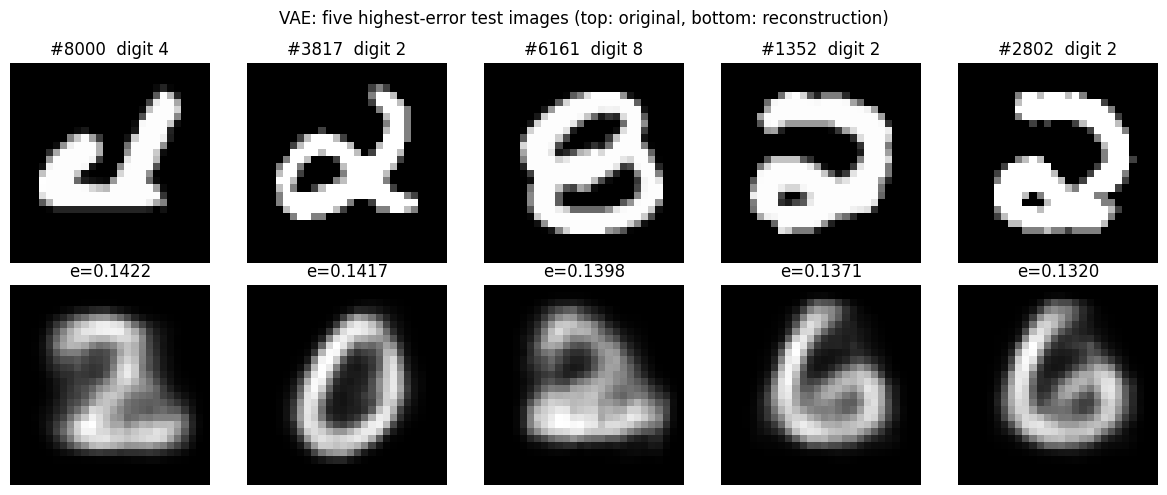

In [33]:

n = 10
rows = [("Original", x_te), ("FC-AE (dz=16)", fc_recons_by_dz[16].reshape(-1, 28, 28, 1)),
        ("CAE", cae_rec), ("Noisy input", x_te_noisy), ("Denoised CAE", dcae_rec), ("VAE (dz=2)", vae_recon)]

plt.figure(figsize=(18, 10))
for r, (name, arr) in enumerate(rows):
    for j in range(n):
        plt.subplot(len(rows), n, r * n + j + 1)
        plt.imshow(arr[j].squeeze(), cmap="gray"); plt.axis("off")
        if j == 0:
            plt.title(name, fontsize=10, loc="left")
plt.tight_layout(); plt.show()

# per-image error e_i for every model (vs. the CLEAN image)
errs = {
    "FC-AE":      np.mean((x_te_flat - fc_recons_by_dz[16]) ** 2, axis=1),
    "CAE":        np.mean((x_te - cae_rec) ** 2, axis=(1, 2, 3)),
    "Denoising":  np.mean((x_te - dcae_rec) ** 2, axis=(1, 2, 3)),
    "VAE":        np.mean((x_te - vae_recon) ** 2, axis=(1, 2, 3)),
}
plt.figure(figsize=(9, 5))
for name, e in errs.items():
    plt.hist(e, bins=60, alpha=0.5, label=f"{name} (median {np.median(e):.4f})")
plt.xlabel("Per-image reconstruction error $e_i$"); plt.ylabel("Number of test images")
plt.title("Distribution of reconstruction errors — all models"); plt.legend(); plt.show()

# five worst VAE reconstructions
worst = np.argsort(errs["VAE"])[-5:][::-1]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for k, idx in enumerate(worst):
    axes[0, k].imshow(x_te[idx].squeeze(), cmap="gray"); axes[0, k].set_title(f"#{idx}  digit {y_test[idx]}"); axes[0, k].axis("off")
    axes[1, k].imshow(vae_recon[idx].squeeze(), cmap="gray"); axes[1, k].set_title(f"e={errs['VAE'][idx]:.4f}"); axes[1, k].axis("off")
axes[0, 0].set_ylabel("Original"); plt.suptitle("VAE: five highest-error test images (top: original, bottom: reconstruction)")
plt.tight_layout(); plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train (60000, 28, 28, 1) test (10000, 28, 28, 1)
ex1 4 {'mse': 0.029325172305107117, 'mae': 0.07253848016262054, 'ssim': 0.693898801830668, 'params': 65797, 'time': 73.56257510185242}
ex1 8 {'mse': 0.016030384227633476, 'mae': 0.04577837139368057, 'ssim': 0.8201049470101665, 'params': 90889, 'time': 71.95590543746948}
ex1 16 {'mse': 0.00725276954472065, 'mae': 0.026711957529187202, 'ssim': 0.924636103573327, 'params': 141073, 'time': 67.82596158981323}
ex1 32 {'mse': 0.003607176709920168, 'mae': 0.0179731622338295, 'ssim': 0.9616139115264104, 'params': 241441, 'time': 66.0621166229248}


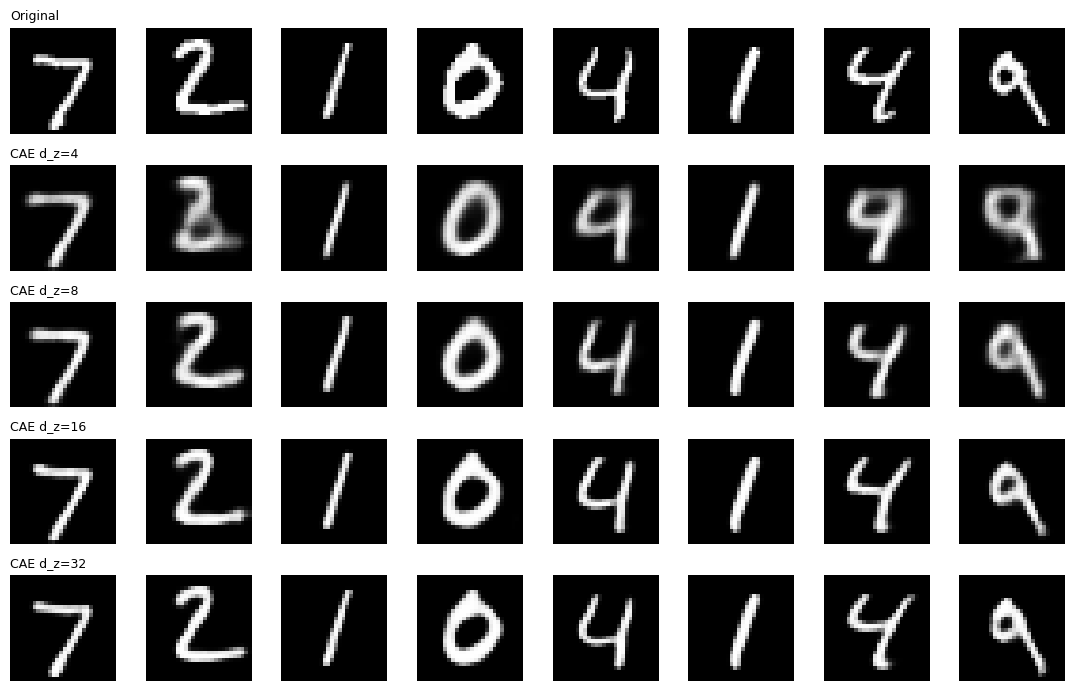

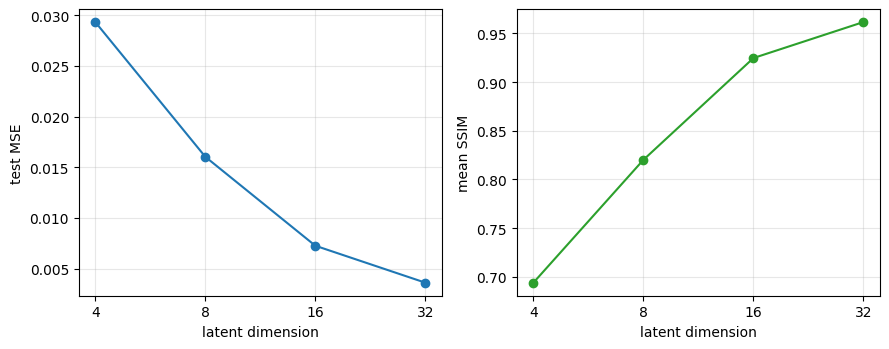

ex4 up {'mse': 0.0010981953237205744, 'mae': 0.009805142879486084, 'ssim': 0.9892590304407453, 'params': 74497, 'time': 67.00210499763489}
ex4 tr {'mse': 0.001053685904480517, 'mae': 0.00947665050625801, 'ssim': 0.99006178479394, 'params': 74497, 'time': 54.233333110809326}


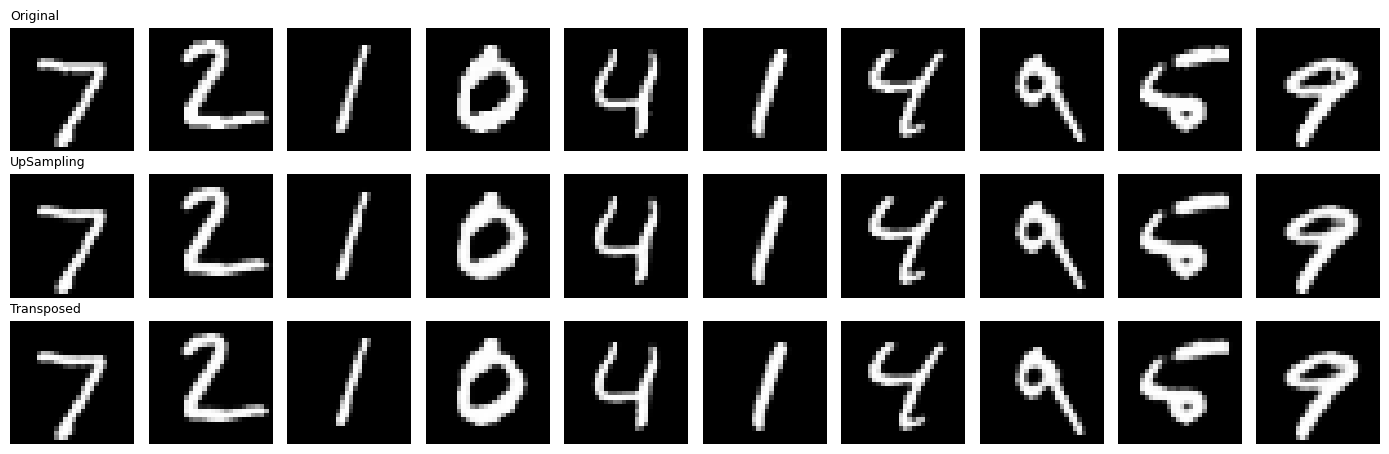

clf acc 0.9656999707221985
ex5 2 {'mse': 0.042943086475133896, 'mae': 0.10099766403436661, 'ssim': 0.5199957154183936, 'time': 98.06376504898071, 'kl_total': 5.969910621643066, 'kl_per_dim': [2.5036447048187256, 3.4662656784057617], 'active_dims': 2, 'mu_std': [0.6729506850242615, 1.1220954656600952]}
ex5 8 {'mse': 0.03492844104766846, 'mae': 0.08517705649137497, 'ssim': 0.6161965137344765, 'time': 99.52872729301453, 'kl_total': 8.317967414855957, 'kl_per_dim': [0.00352104683406651, 2.631779670715332, 0.004726300481706858, 2.9178531169891357, 0.005482761189341545, 0.0034151894506067038, 2.7467586994171143, 0.004430267494171858], 'active_dims': 3, 'mu_std': [0.006733177229762077, 0.9550867676734924, 0.007776996120810509, 1.1607956886291504, 0.004353340715169907, 0.002463084878399968, 0.7188276052474976, 0.008063753135502338]}


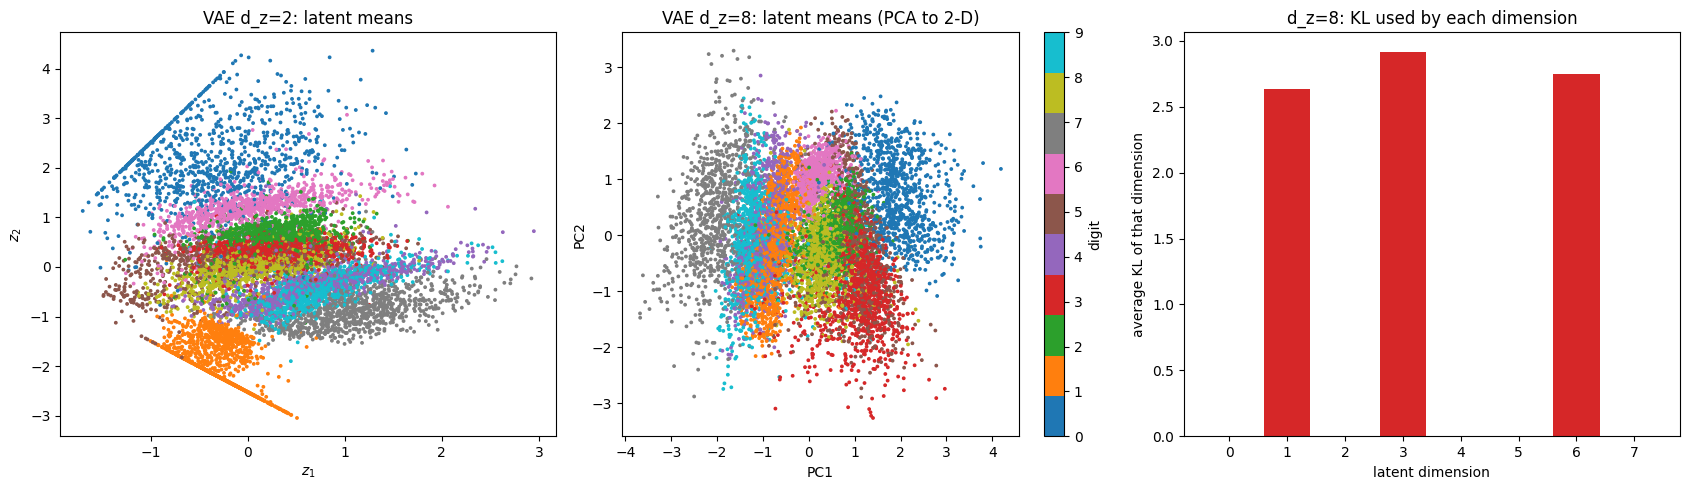

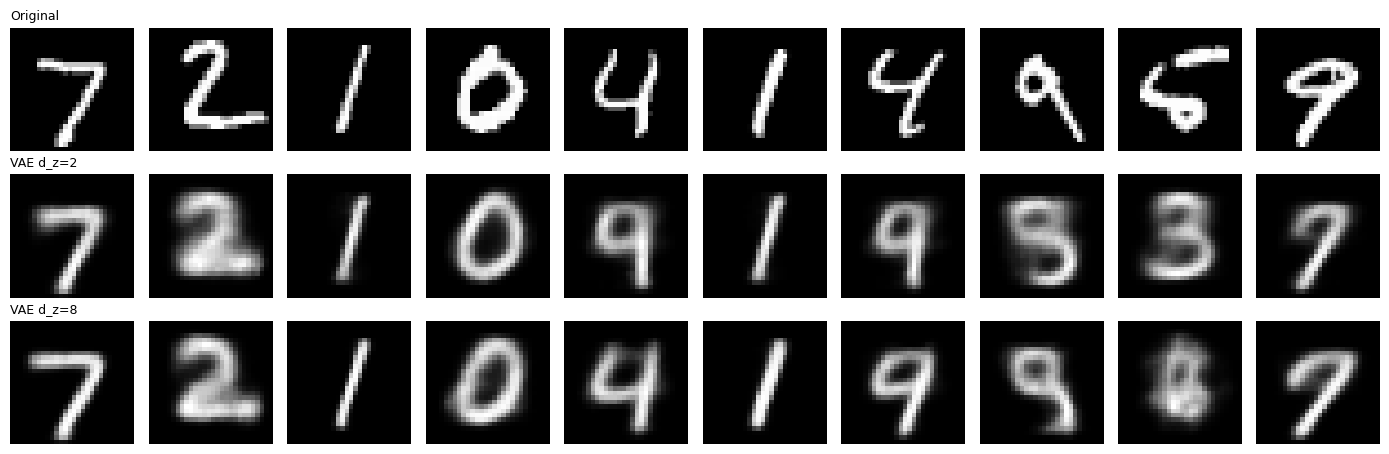

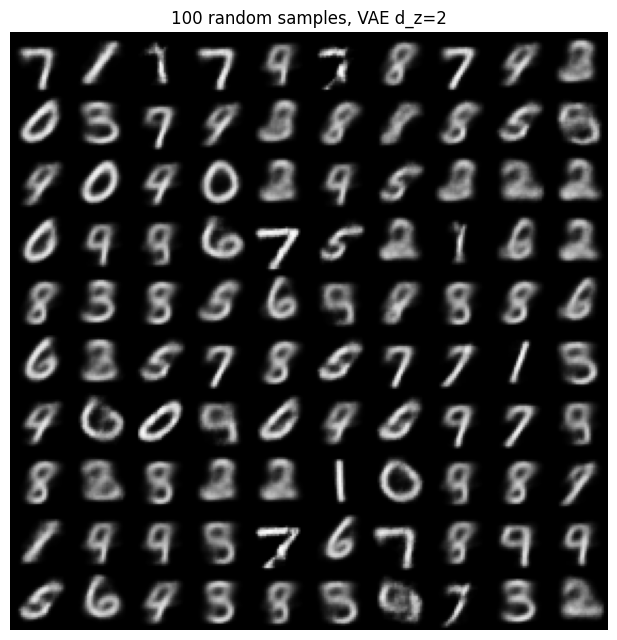

ex7 2 {'counts': [7, 5, 13, 6, 4, 8, 9, 13, 21, 14], 'classes_present': 10, 'mean_conf': 0.8523722290992737, 'low_conf': 29}


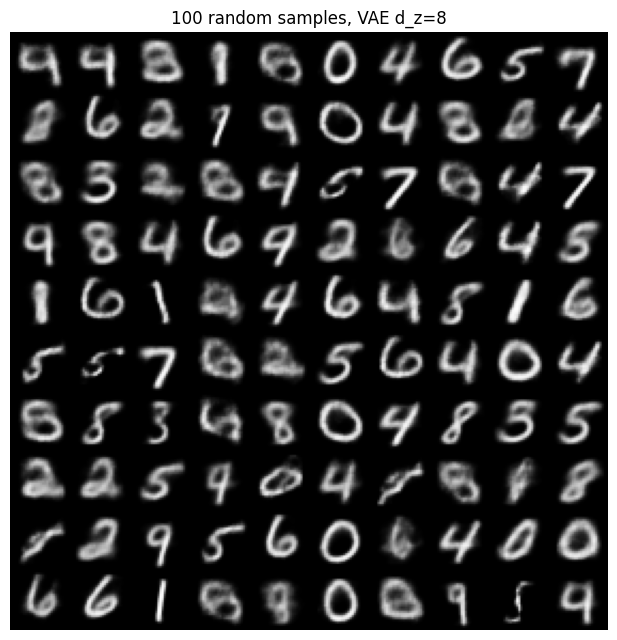

ex7 8 {'counts': [9, 6, 12, 2, 19, 12, 15, 5, 16, 4], 'classes_present': 10, 'mean_conf': 0.8653028011322021, 'low_conf': 33}


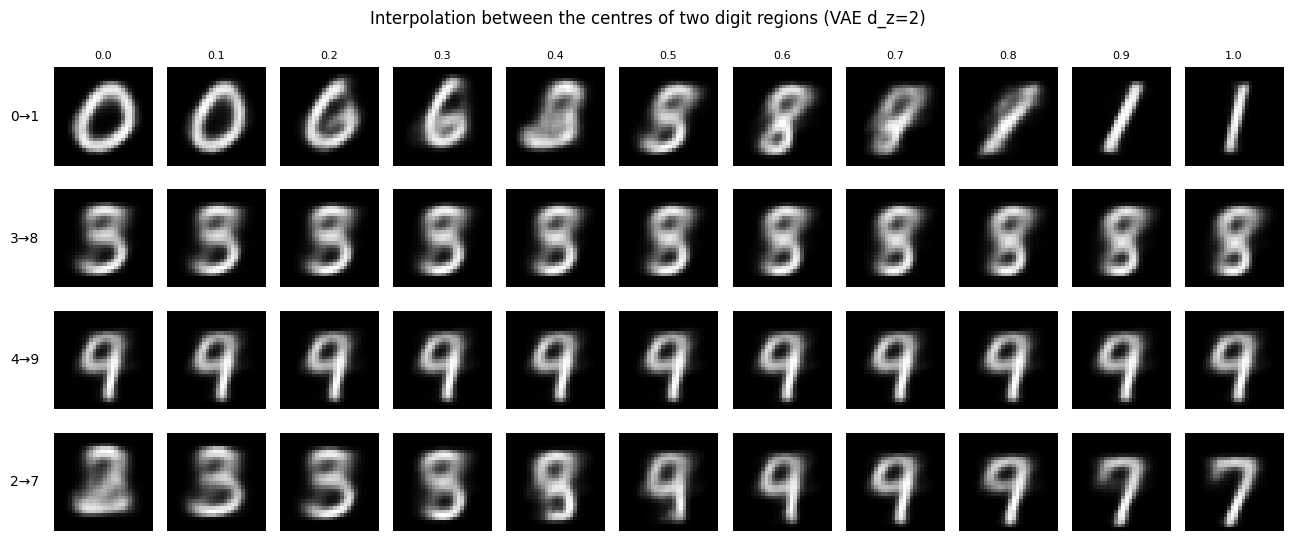

ex6 0.1 {'mse': 0.04059769958257675, 'mae': 0.09648781269788742, 'ssim': 0.5512690888941335, 'kl_total': 11.05655288696289, 'mu_std': [1.5583171844482422, 1.2940081357955933], 'gen_conf': 0.8649691939353943, 'gen_classes': 8, 'time': 97.02824211120605}
ex6 1 {'mse': 0.041358768939971924, 'mae': 0.09798336774110794, 'ssim': 0.5361415750277638, 'kl_total': 6.158447265625, 'mu_std': [1.1087805032730103, 0.9619395136833191], 'gen_conf': 0.8168869614601135, 'gen_classes': 10, 'time': 101.08546328544617}
ex6 5 {'mse': 0.04968097433447838, 'mae': 0.11458077281713486, 'ssim': 0.42358519147425194, 'kl_total': 2.627769947052002, 'mu_std': [1.0208680629730225, 0.0347374752163887], 'gen_conf': 0.7332447171211243, 'gen_classes': 8, 'time': 97.4026231765747}
ex6 20 {'mse': 0.057772036641836166, 'mae': 0.13462744653224945, 'ssim': 0.27258115141646183, 'kl_total': 0.6386747360229492, 'mu_std': [0.7701919674873352, 0.5433971881866455], 'gen_conf': 0.6648041605949402, 'gen_classes': 4, 'time': 94.242544

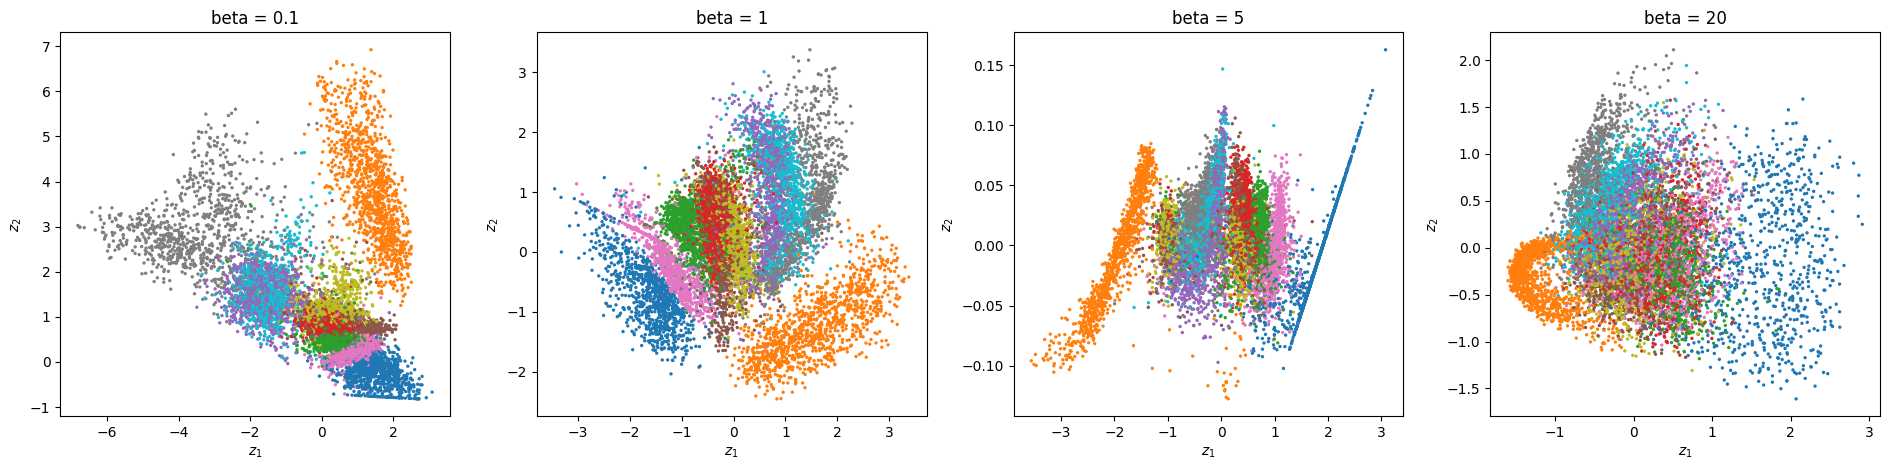

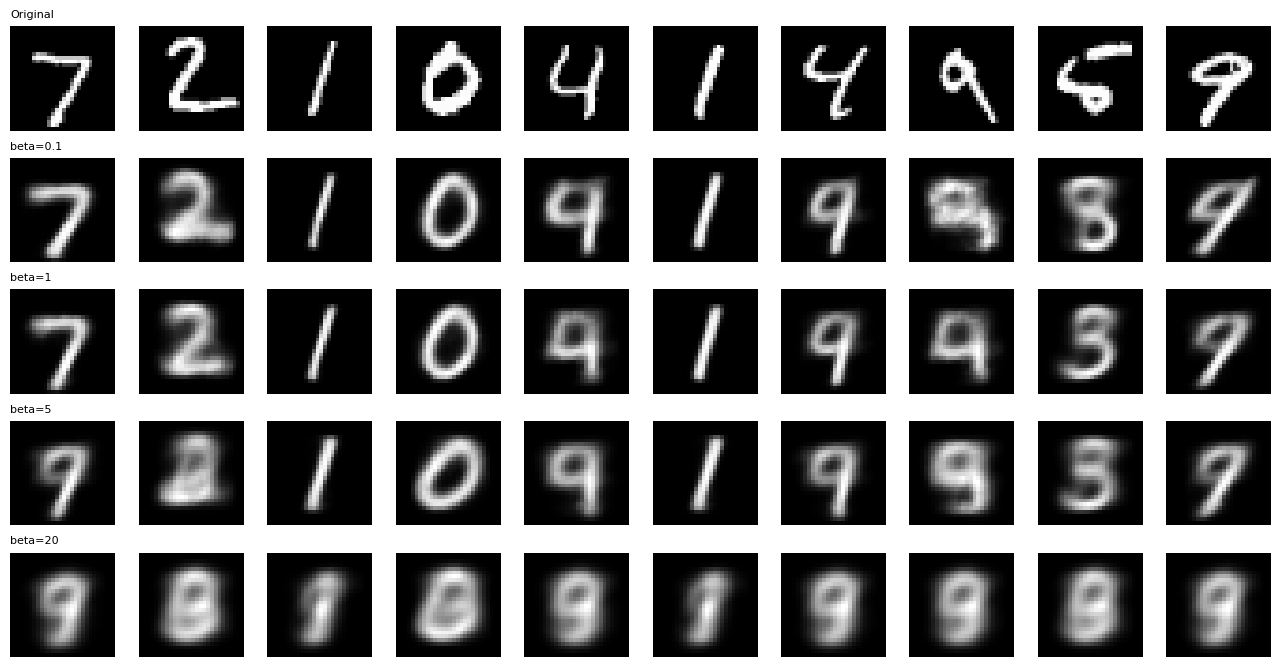

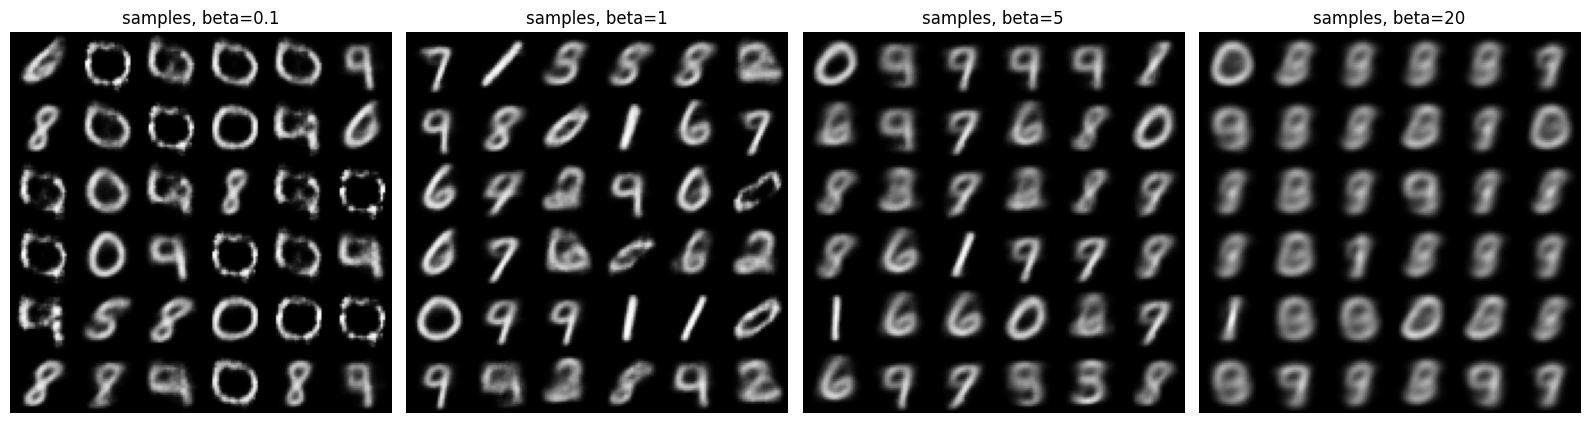

ALL DONE

===== COPY EVERYTHING BELOW AND SEND IT TO ME =====
{
 "ex1_dz4": {
  "mse": 0.029325172305107117,
  "mae": 0.07253848016262054,
  "ssim": 0.693898801830668,
  "params": 65797,
  "time": 73.56257510185242
 },
 "ex1_dz8": {
  "mse": 0.016030384227633476,
  "mae": 0.04577837139368057,
  "ssim": 0.8201049470101665,
  "params": 90889,
  "time": 71.95590543746948
 },
 "ex1_dz16": {
  "mse": 0.00725276954472065,
  "mae": 0.026711957529187202,
  "ssim": 0.924636103573327,
  "params": 141073,
  "time": 67.82596158981323
 },
 "ex1_dz32": {
  "mse": 0.003607176709920168,
  "mae": 0.0179731622338295,
  "ssim": 0.9616139115264104,
  "params": 241441,
  "time": 66.0621166229248
 },
 "ex4_up": {
  "mse": 0.0010981953237205744,
  "mae": 0.009805142879486084,
  "ssim": 0.9892590304407453,
  "params": 74497,
  "time": 67.00210499763489
 },
 "ex4_tr": {
  "mse": 0.001053685904480517,
  "mae": 0.00947665050625801,
  "ssim": 0.99006178479394,
  "params": 74497,
  "time": 54.233333110809326
 },
 

In [1]:

import os, time, json
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
import numpy as np, tensorflow as tf
from tensorflow import keras
from keras import layers, ops
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from sklearn.decomposition import PCA

np.random.seed(42); tf.random.set_seed(42)
SMOKE = bool(int(os.environ.get('SMOKE','0')))          # leave as 0 for the real run
EP, VAE_EP, BS = (20, 30, 128) if not SMOKE else (1, 1, 128)
NSSIM = 10000 if not SMOKE else 300                       # images used for SSIM
os.makedirs('figs_extra', exist_ok=True)

try:
    _xtr, _ytr, _xte, _yte = x_train, y_train, x_test, y_test
except NameError:
    (_xtr,_ytr),(_xte,_yte) = keras.datasets.mnist.load_data()
_xtr = _xtr.astype('float32'); _xte = _xte.astype('float32')
if _xtr.max() > 1.5: _xtr /= 255.0; _xte /= 255.0
xtr = _xtr.reshape(-1,28,28,1); xte = _xte.reshape(-1,28,28,1); ytr = _ytr; yte = _yte
xtr_full, ytr_full = xtr, ytr
if SMOKE: xtr, ytr = xtr[:2000], ytr[:2000]
print('train', xtr.shape, 'test', xte.shape)

R={}
def ev(o,r):
    o=o.reshape(-1,28,28); r=r.reshape(-1,28,28)
    return dict(mse=float(np.mean((o-r)**2)),mae=float(np.mean(np.abs(o-r))),
                ssim=float(np.mean([ssim(o[i],r[i],data_range=1.0) for i in range(NSSIM)])))
def save(): json.dump(R,open('figs_extra/results.json','w'),indent=1)

# ---------- Exercise 1 & 4 : CAE ----------
def enc_block(inp):
    h=layers.Conv2D(32,3,padding='same',activation='relu')(inp); h=layers.MaxPooling2D(2,padding='same')(h)
    h=layers.Conv2D(64,3,padding='same',activation='relu')(h); return layers.MaxPooling2D(2,padding='same')(h)
def cae_dz(dz):
    inp=keras.Input((28,28,1)); h=layers.Flatten()(enc_block(inp)); h=layers.Dense(dz,name='latent')(h)
    h=layers.Dense(3136,activation='relu')(h); h=layers.Reshape((7,7,64))(h)
    h=layers.UpSampling2D(2)(h); h=layers.Conv2D(32,3,padding='same',activation='relu')(h); h=layers.UpSampling2D(2)(h)
    return keras.Model(inp,layers.Conv2D(1,3,padding='same',activation='sigmoid')(h))
def cae_up():
    inp=keras.Input((28,28,1)); h=enc_block(inp); h=layers.Conv2D(64,3,padding='same',activation='relu')(h)
    h=layers.UpSampling2D(2)(h); h=layers.Conv2D(32,3,padding='same',activation='relu')(h); h=layers.UpSampling2D(2)(h)
    return keras.Model(inp,layers.Conv2D(1,3,padding='same',activation='sigmoid')(h))
def cae_tr():
    inp=keras.Input((28,28,1)); h=enc_block(inp); h=layers.Conv2D(64,3,padding='same',activation='relu')(h)
    h=layers.Conv2DTranspose(32,3,strides=2,padding='same',activation='relu')(h)
    return keras.Model(inp,layers.Conv2DTranspose(1,3,strides=2,padding='same',activation='sigmoid')(h))
def fit(m):
    m.compile('adam','binary_crossentropy'); t=time.time()
    m.fit(xtr,xtr,epochs=EP,batch_size=BS,verbose=0); return time.time()-t
recs={}
for dz in [4,8,16,32]:
    m=cae_dz(dz); t=fit(m); r=m.predict(xte,verbose=0); recs[dz]=r[:8]
    R[f'ex1_dz{dz}']=dict(**ev(xte,r),params=m.count_params(),time=t); print('ex1',dz,R[f'ex1_dz{dz}'],flush=True); save()
fig,ax=plt.subplots(5,8,figsize=(11,7))
for j in range(8): ax[0,j].imshow(xte[j,...,0],cmap='gray'); ax[0,j].axis('off')
for i,dz in enumerate([4,8,16,32],1):
    for j in range(8): ax[i,j].imshow(recs[dz][j,...,0],cmap='gray'); ax[i,j].axis('off')
    ax[i,0].set_title(f'CAE d_z={dz}',fontsize=9,loc='left')
ax[0,0].set_title('Original',fontsize=9,loc='left'); plt.tight_layout(); plt.savefig('figs_extra/ex1_recon.png',dpi=110); plt.show()
dzs=[4,8,16,32]; fig,a=plt.subplots(1,2,figsize=(9,3.6))
a[0].plot(dzs,[R[f'ex1_dz{k}']['mse'] for k in dzs],'o-'); a[0].set_xscale('log',base=2); a[0].set_xticks(dzs); a[0].set_xticklabels(dzs); a[0].set_xlabel('latent dimension'); a[0].set_ylabel('test MSE'); a[0].grid(alpha=.3)
a[1].plot(dzs,[R[f'ex1_dz{k}']['ssim'] for k in dzs],'o-',color='tab:green'); a[1].set_xscale('log',base=2); a[1].set_xticks(dzs); a[1].set_xticklabels(dzs); a[1].set_xlabel('latent dimension'); a[1].set_ylabel('mean SSIM'); a[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig('figs_extra/ex1_plot.png',dpi=110); plt.show()

outs={}
for name,fn in [('up',cae_up),('tr',cae_tr)]:
    m=fn(); t=fit(m); r=m.predict(xte,verbose=0); outs[name]=r
    R[f'ex4_{name}']=dict(**ev(xte,r),params=m.count_params(),time=t); print('ex4',name,R[f'ex4_{name}'],flush=True); save()
fig,ax=plt.subplots(3,10,figsize=(14,4.6))
for j in range(10):
    for i,(im,tt) in enumerate([(xte[j],'Original'),(outs['up'][j],'UpSampling'),(outs['tr'][j],'Transposed')]):
        ax[i,j].imshow(im[...,0],cmap='gray'); ax[i,j].axis('off')
        if j==0: ax[i,j].set_title(tt,fontsize=9,loc='left')
plt.tight_layout(); plt.savefig('figs_extra/ex4_recon.png',dpi=110); plt.show()

# ---------- VAE ----------
class Sampling(layers.Layer):
    def __init__(s,**k): super().__init__(**k); s.sg=keras.random.SeedGenerator(1337)
    def call(s,x):
        m,lv=x; e=keras.random.normal((ops.shape(m)[0],ops.shape(m)[1]),seed=s.sg); return m+ops.exp(.5*lv)*e
def build_vae(dz):
    i=keras.Input((28,28,1)); h=layers.Conv2D(32,3,strides=2,padding='same',activation='relu')(i)
    h=layers.Conv2D(64,3,strides=2,padding='same',activation='relu')(h); h=layers.Flatten()(h); h=layers.Dense(16,activation='relu')(h)
    zm=layers.Dense(dz)(h); zl=layers.Dense(dz)(h); z=Sampling()([zm,zl]); enc=keras.Model(i,[zm,zl,z])
    di=keras.Input((dz,)); d_=layers.Dense(3136,activation='relu')(di); d_=layers.Reshape((7,7,64))(d_)
    d_=layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(d_); d_=layers.Conv2DTranspose(32,3,strides=2,padding='same',activation='relu')(d_)
    dec=keras.Model(di,layers.Conv2DTranspose(1,3,padding='same',activation='sigmoid')(d_)); return enc,dec
class VAE(keras.Model):
    def __init__(s,enc,dec,beta=1.0): super().__init__(); s.enc=enc; s.dec=dec; s.beta=beta
    def train_step(s,data):
        if isinstance(data,(tuple,list)): data=data[0]
        with tf.GradientTape() as tp:
            m,lv,z=s.enc(data); r=s.dec(z)
            rec=ops.mean(ops.sum(keras.losses.binary_crossentropy(data,r),axis=(1,2)))
            kl=-0.5*ops.mean(ops.sum(1+lv-ops.square(m)-ops.exp(lv),axis=1)); tot=rec+s.beta*kl
        g=tp.gradient(tot,s.trainable_weights); s.optimizer.apply_gradients(zip(g,s.trainable_weights)); return {'loss':tot}
def train_vae(dz,beta=1.0):
    enc,dec=build_vae(dz); v=VAE(enc,dec,beta); v.compile(optimizer=keras.optimizers.Adam(1e-3))
    t=time.time(); v.fit(xtr,epochs=VAE_EP,batch_size=BS,verbose=0); return enc,dec,time.time()-t
def vae_eval(enc,dec):
    m,lv,_=enc.predict(xte,verbose=0); r=dec.predict(m,verbose=0)
    klper=-0.5*np.mean(1+lv-m**2-np.exp(lv),axis=0)
    return m,lv,r,klper
np.random.seed(0)
# classifier for diversity
clf=keras.Sequential([layers.Input((28,28,1)),layers.Flatten(),layers.Dense(128,activation='relu'),layers.Dense(10,activation='softmax')])
clf.compile('adam','sparse_categorical_crossentropy',metrics=['accuracy']); clf.fit(xtr_full,ytr_full,epochs=3,batch_size=128,verbose=0)
R['clf_acc']=float(clf.evaluate(xte,yte,verbose=0)[1]); print('clf acc',R['clf_acc'],flush=True)

# ---------- Exercise 5 : VAE dz 2 vs 8 ----------
V={}
for dz in [2,8]:
    enc,dec,t=train_vae(dz); m,lv,r,kp=vae_eval(enc,dec); V[dz]=(enc,dec,m,lv,r)
    R[f'ex5_dz{dz}']=dict(**ev(xte,r),time=t,kl_total=float(kp.sum()),kl_per_dim=[float(k) for k in kp],
        active_dims=int((kp>0.1).sum()),mu_std=[float(s) for s in m.std(0)]); print('ex5',dz,R[f'ex5_dz{dz}'],flush=True); save()
m8=V[8][2]; pca=PCA(2).fit(m8); p8=pca.transform(m8); R['ex5_pca_var']=[float(v) for v in pca.explained_variance_ratio_]
fig,a=plt.subplots(1,3,figsize=(17,5))
s=a[0].scatter(V[2][2][:,0],V[2][2][:,1],c=yte,cmap='tab10',s=3); a[0].set_title('VAE d_z=2: latent means'); a[0].set_xlabel('$z_1$'); a[0].set_ylabel('$z_2$')
a[1].scatter(p8[:,0],p8[:,1],c=yte,cmap='tab10',s=3); a[1].set_title('VAE d_z=8: latent means (PCA to 2-D)'); a[1].set_xlabel('PC1'); a[1].set_ylabel('PC2')
w=.4; a[2].bar(np.arange(8)-0,R['ex5_dz8']['kl_per_dim'],color='tab:red'); a[2].set_xlabel('latent dimension'); a[2].set_ylabel('average KL of that dimension'); a[2].set_title('d_z=8: KL used by each dimension')
plt.colorbar(s,ax=a[1],label='digit'); plt.tight_layout(); plt.savefig('figs_extra/ex5_latent.png',dpi=110); plt.show()
fig,ax=plt.subplots(3,10,figsize=(14,4.6))
for j in range(10):
    for i,(im,tt) in enumerate([(xte[j],'Original'),(V[2][4][j],'VAE d_z=2'),(V[8][4][j],'VAE d_z=8')]):
        ax[i,j].imshow(im[...,0],cmap='gray'); ax[i,j].axis('off')
        if j==0: ax[i,j].set_title(tt,fontsize=9,loc='left')
plt.tight_layout(); plt.savefig('figs_extra/ex5_recon.png',dpi=110); plt.show()

# ---------- Exercise 7 : bigger random grid + diversity ----------
def grid(dec,dz,n=10,seed=1):
    z=np.random.RandomState(seed).randn(n*n,dz).astype('float32'); g=dec.predict(z,verbose=0); return g
for dz in [2,8]:
    g=grid(V[dz][1],dz,10); lab=clf.predict(g,verbose=0); pred=lab.argmax(1); conf=lab.max(1)
    cnt=np.bincount(pred,minlength=10); R[f'ex7_dz{dz}']=dict(counts=[int(c) for c in cnt],classes_present=int((cnt>0).sum()),mean_conf=float(conf.mean()),low_conf=int((conf<0.8).sum()))
    big=np.vstack([np.hstack(list(g[i*10:(i+1)*10,...,0])) for i in range(10)])
    plt.figure(figsize=(6.5,6.5)); plt.imshow(big,cmap='gray'); plt.axis('off'); plt.title(f'100 random samples, VAE d_z={dz}'); plt.tight_layout(); plt.savefig(f'figs_extra/ex7_grid_dz{dz}.png',dpi=110); plt.show()
    print('ex7',dz,R[f'ex7_dz{dz}'],flush=True)
save()

# ---------- Exercise 8 : interpolate between two digit regions (class centroids), d_z=2 ----------
m2=V[2][2]; dec2=V[2][1]; cen={k:m2[yte==k].mean(0) for k in range(10)}
pairs=[(0,1),(3,8),(4,9),(2,7)]; al=np.linspace(0,1,11)
fig,ax=plt.subplots(len(pairs),11,figsize=(13,1.25*len(pairs)+.6))
for r_,(a_,b_) in enumerate(pairs):
    zz=np.array([(1-t)*cen[a_]+t*cen[b_] for t in al],dtype='float32'); im=dec2.predict(zz,verbose=0)
    for c in range(11):
        ax[r_,c].imshow(im[c,...,0],cmap='gray'); ax[r_,c].axis('off')
        if r_==0: ax[r_,c].set_title(f'{al[c]:.1f}',fontsize=8)
    ax[r_,0].text(-0.15,0.5,f'{a_}→{b_}',transform=ax[r_,0].transAxes,ha='right',va='center',fontsize=10)
plt.suptitle('Interpolation between the centres of two digit regions (VAE d_z=2)'); plt.tight_layout(); plt.savefig('figs_extra/ex8_interp.png',dpi=110); plt.show()
R['ex8_centroids']={str(k):[float(v) for v in cen[k]] for k in range(10)}; save()

# ---------- Exercise 6 : KL weight (beta) ----------
betas=[0.1,1,5,20]; VB={}
for b in betas:
    enc,dec,t=train_vae(2,b); m,lv,r,kp=vae_eval(enc,dec); VB[b]=(enc,dec,m,r)
    g=grid(dec,2,10); lab=clf.predict(g,verbose=0)
    R[f'ex6_b{b}']=dict(**ev(xte,r),kl_total=float(kp.sum()),mu_std=[float(s) for s in m.std(0)],gen_conf=float(lab.max(1).mean()),gen_classes=int(len(set(lab.argmax(1)))),time=t)
    print('ex6',b,R[f'ex6_b{b}'],flush=True); save()
fig,a=plt.subplots(1,4,figsize=(19,4.8))
for k,b in enumerate(betas):
    mm=VB[b][2]; s=a[k].scatter(mm[:,0],mm[:,1],c=yte,cmap='tab10',s=2); a[k].set_title(f'beta = {b}'); a[k].set_xlabel('$z_1$'); a[k].set_ylabel('$z_2$')
plt.tight_layout(); plt.savefig('figs_extra/ex6_latent.png',dpi=105); plt.show()
fig,ax=plt.subplots(len(betas)+1,10,figsize=(13,1.35*(len(betas)+1)))
for j in range(10):
    ax[0,j].imshow(xte[j,...,0],cmap='gray'); ax[0,j].axis('off')
    for i,b in enumerate(betas,1): ax[i,j].imshow(VB[b][3][j,...,0],cmap='gray'); ax[i,j].axis('off')
ax[0,0].set_title('Original',fontsize=8,loc='left')
for i,b in enumerate(betas,1): ax[i,0].set_title(f'beta={b}',fontsize=8,loc='left')
plt.tight_layout(); plt.savefig('figs_extra/ex6_recon.png',dpi=110); plt.show()
fig,ax=plt.subplots(1,4,figsize=(16,4.2))
for k,b in enumerate(betas):
    g=grid(VB[b][1],2,6,seed=3); big=np.vstack([np.hstack(list(g[i*6:(i+1)*6,...,0])) for i in range(6)]); ax[k].imshow(big,cmap='gray'); ax[k].axis('off'); ax[k].set_title(f'samples, beta={b}')
plt.tight_layout(); plt.savefig('figs_extra/ex6_samples.png',dpi=110); plt.show()
print('ALL DONE')
print('\n===== COPY EVERYTHING BELOW AND SEND IT TO ME =====')
print(json.dumps(R,indent=1))